# ============================================================
# E-COMMERCE BUSINESS ANALYSIS - 2019
# Scaler Academy | EDA Project
# Author: Pritam Biswas
# Dataset: E-Commerce Transactions (Jan 2019 - Dec 2019)
# ============================================================

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load Data from Google Drive



In [3]:
import os

folder = '/content/drive/MyDrive/DataSets/Scaler_Project_1/'
files = os.listdir(folder)
for f in files:
    print(f)

Online_Sales.csv
CustomersData.xlsx
Tax_amount.xlsx
Marketing_Spend.csv
Discount_Coupon.csv
Dataset Description.docx


# Import Libraries


In [4]:
# --- Core Libraries ---
import pandas as pd
import numpy as np
from IPython.display import display

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Statistics ---
from scipy import stats

# --- Display ---
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", None)


# Load All Datasets

In [5]:
file_path = '/content/drive/MyDrive/DataSets/Scaler_Project_1/'

online_sales = pd.read_csv(file_path + 'Online_Sales.csv')
customers = pd.read_excel(file_path + 'CustomersData.xlsx')
discount_coupon = pd.read_csv(file_path + 'Discount_Coupon.csv')
marketing = pd.read_csv(file_path + 'Marketing_Spend.csv')
tax = pd.read_excel(file_path + 'Tax_amount.xlsx')


print("All Datasets are loaded successfully!!!!!!")
print("=" * 50, "\n")

print(f"Online Sales :  {online_sales.shape}")
print(f"Customer Data : {customers.shape}")
print(f"Discount Coupon : {discount_coupon.shape}")
print(f"MArketing Spend : {marketing.shape}")
print(f"Tax Amount : {tax.shape}")



All Datasets are loaded successfully!!!!!!

Online Sales :  (52924, 10)
Customer Data : (1468, 4)
Discount Coupon : (204, 4)
MArketing Spend : (365, 3)
Tax Amount : (20, 2)


# View the Data

In [6]:
def inspect_data(df, dataset_name):
    print("=" * 70)
    print(dataset_name.upper())
    print("=" * 70)

    print("\nFirst 3 Rows:")
    print("-" * 70)
    display(df.head(3))

    print("\nData Types:")
    print("-" * 70)
    display(df.dtypes)

    print("\nData Info:")
    print("-" * 70)
    df.info()

    print("\nSummary Statistics - Numeric Columns:")
    print("-" * 70)
    display(df.describe().T)

    print("\nSummary Statistics - All Columns:")
    print("-" * 70)
    display(df.describe(include="all").T)

    print("\n\n")

In [105]:
%%capture
inspect_data(online_sales, "Online Sales")
inspect_data(customers, "Customer Data")
inspect_data(discount_coupon, "Discount Coupon")
inspect_data(marketing, "Marketing Spend")
inspect_data(tax, "Tax Amount")

# Q:1 - Identify the months with the highest and lowest acquisition count. What strategies could be implemented to address the fluctuations and ensure consistent growth throughout the year

In [8]:
# We are assuming, Customer acquisition month = month of customer's first transaction as no Acquisition date is given in the Customer table

# Converting the transaction date to datetime
online_sales['Transaction_Date'] = pd.to_datetime(online_sales['Transaction_Date'])

# Finding first transaction date for each customers
customer_acquisition = online_sales.groupby('CustomerID')['Transaction_Date'].min().reset_index()
#customer_acquisition

# Extracting acquisition month
customer_acquisition['Acquisition_Month'] = customer_acquisition['Transaction_Date'].dt.month_name()
#customer_acquisition

# Extracting month number
customer_acquisition['Month_Number'] = customer_acquisition['Transaction_Date'].dt.month
#customer_acquisition

# Counting number of new customers added per month
monthly_acquisition = customer_acquisition.groupby(['Month_Number','Acquisition_Month'])['CustomerID'].nunique()\
    .reset_index(name='Acquisition_Count')

display(monthly_acquisition)

,Month_Number,Acquisition_Month,Acquisition_Count
0,1,January,215
1,2,February,96
2,3,March,177
3,4,April,163
4,5,May,112
5,6,June,137
6,7,July,94
7,8,August,135
8,9,September,78
9,10,October,87


# Highest and Lowest acquisition month

In [9]:
months_with_highest_acquisition = monthly_acquisition[monthly_acquisition['Acquisition_Count'] == monthly_acquisition['Acquisition_Count'].max()]

print("\nHighest Acquisition Month:")
print("-" * 70)
display(months_with_highest_acquisition[['Acquisition_Month', 'Acquisition_Count']])

months_with_lowest_acquisition = monthly_acquisition[monthly_acquisition['Acquisition_Count'] == monthly_acquisition['Acquisition_Count'].min()]
print("\nLowest Acquisition Month:")
print("-" * 70)
display(months_with_lowest_acquisition[['Acquisition_Month', 'Acquisition_Count']])


Highest Acquisition Month:
----------------------------------------------------------------------


,Acquisition_Month,Acquisition_Count
0,January,215



Lowest Acquisition Month:
----------------------------------------------------------------------


,Acquisition_Month,Acquisition_Count
10,November,68


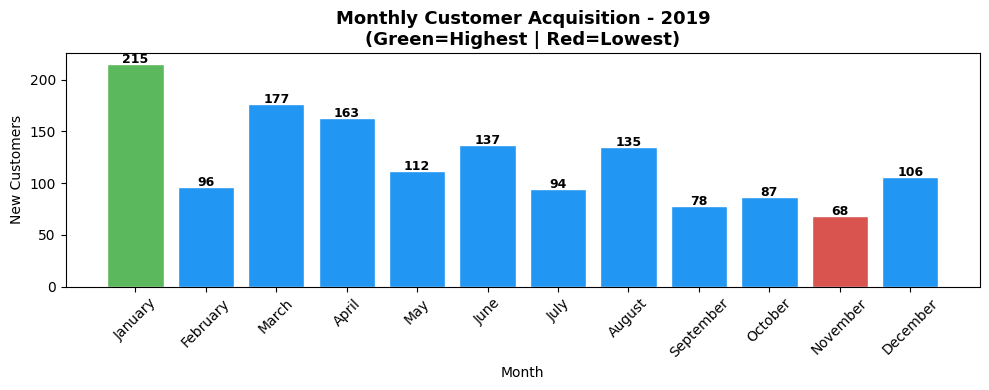

In [99]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#d9534f' if x == monthly_acquisition['Acquisition_Count'].min()
          else '#5cb85c' if x == monthly_acquisition['Acquisition_Count'].max()
          else '#2196F3' for x in monthly_acquisition['Acquisition_Count']]
bars = ax.bar(monthly_acquisition['Acquisition_Month'],
              monthly_acquisition['Acquisition_Count'],
              color=colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            str(int(bar.get_height())),
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('Monthly Customer Acquisition - 2019\n(Green=Highest | Red=Lowest)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('New Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Analysis:
Assumption: Since CustomersData lacks a direct acquisition date, each customer's first transaction date has been used as their acquisition date.

Finding: January had the highest acquisition (215 customers) and November the lowest (68) - a 3x gap. Notably, November and December had the highest marketing spend (1.61L and 1.99L) yet weakest acquisition, suggesting Q4 spend drives repeat purchases rather than new customer growth.

Strategies:
Redirect a portion of Q4 budget toward first-time buyer offers and referral campaigns
Introduce welcome coupons in low-acquisition months (July, September, November)
Double down on January's natural momentum with strong onboarding campaigns
Audit underperforming channels in September and October where spend doesn't convert

#Q:2 - Analyze the data to determine if certain months consistently show higher or lower monthly acquisitions. How can the company capitalize on high-performing months and improve performance during slower periods?

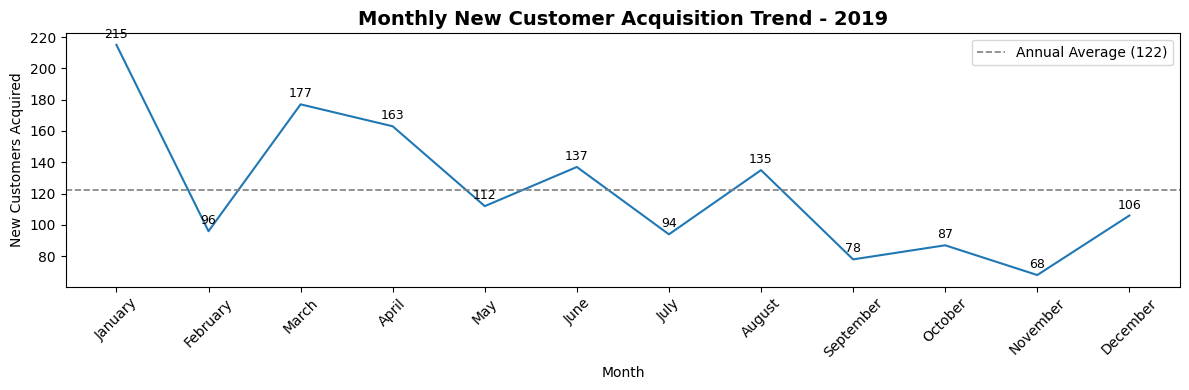

Above Average Acquisition Months:


,Acquisition_Month,Acquisition_Count
0,January,215
2,March,177
3,April,163
5,June,137
7,August,135


Below Average Acquisition Months:


,Acquisition_Month,Acquisition_Count
1,February,96
4,May,112
6,July,94
8,September,78
9,October,87
10,November,68
11,December,106


In [75]:
# ============================================================
# Q2: Monthly Acquisition Trend - Patterns Across the Year
# ============================================================

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(monthly_acquisition['Acquisition_Month'],
        monthly_acquisition['Acquisition_Count']
        )

# Shade high and low zones
avg = monthly_acquisition['Acquisition_Count'].mean()
ax.axhline(avg, color='gray', linestyle='--',
           linewidth=1.2, label=f'Annual Average ({avg:.0f})')

# Annotate each point
for _, row in monthly_acquisition.iterrows():
    ax.annotate(str(int(row['Acquisition_Count'])),
                (row['Acquisition_Month'], row['Acquisition_Count']),
                textcoords="offset points",
                xytext=(0, 5), ha='center', fontsize=9)

ax.set_title('Monthly New Customer Acquisition Trend - 2019',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('New Customers Acquired')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# display the outcome
above_avg = monthly_acquisition[monthly_acquisition['Acquisition_Count'] > avg][['Acquisition_Month', 'Acquisition_Count']]
below_avg = monthly_acquisition[monthly_acquisition['Acquisition_Count'] < avg][['Acquisition_Month', 'Acquisition_Count']]

print("Above Average Acquisition Months:")
display(above_avg)

print("Below Average Acquisition Months:")
display(below_avg)

#Analysis:
The data reveals a clear H1 vs H2 divide - January, March, April, June
and August outperform the annual average (122/month), while every month
from July to December falls below it, indicating a structural H2 slowdown.

Strategies:


1.  Scale marketing in strong H1 months (March, April) to maximise returns
2.  Launch first-time buyer offers in the three weakest months (September, October, November) to stimulate H2 acquisition
3.  Onboard H1 new customers into loyalty programs to retain them through H2



#Q:3 -Identify periods with the strongest and weakest retention rates. What strategies could be implemented to improve retention during weaker months?

In [81]:
# ============================================================
# Q3: Monthly Retention Rate
# ============================================================

# Ensure Transaction_Date is datetime and extract month number/name
online_sales['Transaction_Date'] = pd.to_datetime(online_sales['Transaction_Date'])
online_sales['Month_Number'] = online_sales['Transaction_Date'].dt.month
online_sales['Month_Name'] = online_sales['Transaction_Date'].dt.month_name()

# Get all unique customers per month (active customers)
monthly_active = (online_sales.groupby(['Month_Number', 'Month_Name'])['CustomerID']
                            .nunique()
                            .reset_index(name='Active_Customers')
                            .sort_values('Month_Number'))
display('Monthly Active Customers: ', monthly_active)

# Get new customers per month (from Q1)
new_customers = monthly_acquisition.rename(
    columns={
        'Acquisition_Count': 'New_Customers',
        'Acquisition_Month': 'Month_Name'
    })
display('Monthly New Customers: ', new_customers)

# Merge the results and calculate returning customers
retention_df = monthly_active.merge(new_customers, on='Month_Number', how='left')

retention_df['Returning_Customers'] = (
    retention_df['Active_Customers'] - retention_df['New_Customers'])
#retention_df

# Retention Rate
retention_df['Retention_Rate_%'] = (
    (retention_df['Returning_Customers'] / retention_df['Active_Customers']) * 100
).round(2)
display('Retention Percentage: ', retention_df[[
    'Month_Name_x', 'Active_Customers', 'New_Customers',
    'Returning_Customers', 'Retention_Rate_%']])

'Monthly Active Customers: '

,Month_Number,Month_Name,Active_Customers
0,1,January,215
1,2,February,109
2,3,March,208
3,4,April,224
4,5,May,200
5,6,June,259
6,7,July,236
7,8,August,300
8,9,September,193
9,10,October,210


'Monthly New Customers: '

,Month_Number,Month_Name,New_Customers
0,1,January,215
1,2,February,96
2,3,March,177
3,4,April,163
4,5,May,112
5,6,June,137
6,7,July,94
7,8,August,135
8,9,September,78
9,10,October,87


'Retention Percentage: '

,Month_Name_x,Active_Customers,New_Customers,Returning_Customers,Retention_Rate_%
0,January,215,215,0,0.00
1,February,109,96,13,11.93
2,March,208,177,31,14.90
3,April,224,163,61,27.23
4,May,200,112,88,44.00
5,June,259,137,122,47.10
6,July,236,94,142,60.17
7,August,300,135,165,55.00
8,September,193,78,115,59.59
9,October,210,87,123,58.57


# Visualise The Data

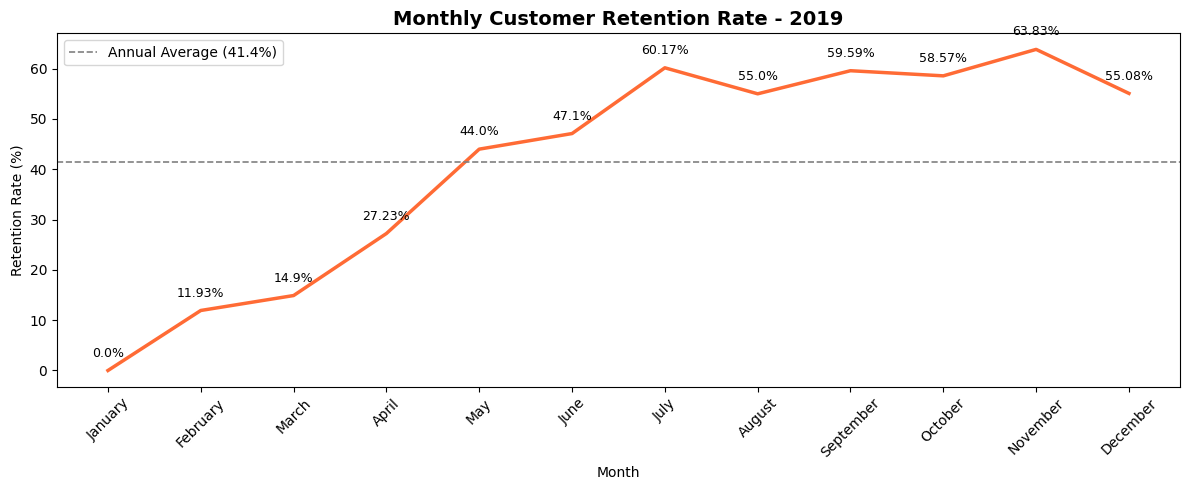

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(retention_df['Month_Name_x'],
        retention_df['Retention_Rate_%'],
         linewidth=2.5, color='#FF6B35',)

avg_retention = retention_df['Retention_Rate_%'].mean()
ax.axhline(avg_retention, color='gray', linestyle='--',
           linewidth=1.2, label=f'Annual Average ({avg_retention:.1f}%)')

for _, row in retention_df.iterrows():
    ax.annotate(f"{row['Retention_Rate_%']}%",
                (row['Month_Name_x'], row['Retention_Rate_%']),
                textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=9)

ax.set_title('Monthly Customer Retention Rate - 2019',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Retention Rate (%)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analysis:
Retention shows a steady upward trend throughout 2019, rising from 0% in January (all customers were new) to a peak of 63.83% in November. H2 consistently outperforms H1 in retention - the inverse of the acquisition pattern seen in Q2 - suggesting that customers acquired early in the year are returning and becoming loyal buyers by mid-year.



1.   Weakest retention period: January–April (0% to 27%)
2.   Strongest retention period: July–November (55%–64%)




Strategies to improve retention in weaker months:


*   Launch post-purchase email sequences for H1 new customers to encourage a second purchase within 30 days
*   Offer loyalty points or rewards redeemable in H2 to incentivise early customers to return
*   Introduce subscription or membership programs targeting January and February buyers before they go cold






# Q:4 -Analyze customer behavior during high-retention months and suggest ways to replicate this success throughout the year.

In [13]:
# ============================================================
# Q4: Customer Behavior in High vs Low Retention Months
# ============================================================

# Define high and low retention months based on Q3 findings
high_retention_months = [7,8,9,10,11]
low_retention_months = [1,2,3,4]

# Add retention peiord label to online_sales
online_sales['Retention_Period'] = online_sales['Month_Number'].apply(
    lambda x: 'High Retention' if x in high_retention_months
    else ('Low Retention' if x in low_retention_months
          else 'Mid')
)

#display(online_sales)

# --- Analysis 1: Category Mix --- #
category_behaviour  = online_sales[online_sales['Retention_Period'] != 'Mid']\
.groupby(['Retention_Period','Product_Category'])['Transaction_ID'].count()\
.reset_index(name='Transaction_Count')\
.sort_values(['Retention_Period','Transaction_Count'], ascending=[True,False])

#display(category_behaviour)
print('Top 5 Categories by Retention Period:')
for period in ['High Retention', 'Low Retention']:
  print(f"\n{period}")
  display(category_behaviour[category_behaviour['Retention_Period'] == period].head(5).reset_index(drop = True))


Top 5 Categories by Retention Period:

High Retention


,Retention_Period,Product_Category,Transaction_Count
0,High Retention,Apparel,8383
1,High Retention,Nest-USA,5724
2,High Retention,Office,2571
3,High Retention,Lifestyle,1593
4,High Retention,Drinkware,1550



Low Retention


,Retention_Period,Product_Category,Transaction_Count
0,Low Retention,Apparel,4884
1,Low Retention,Nest-USA,4713
2,Low Retention,Office,2339
3,Low Retention,Drinkware,1247
4,Low Retention,Lifestyle,896


In [14]:
# --- Analysis 2: Coupon Usgae --- #
coupon_behaviour = online_sales[online_sales['Retention_Period'] != 'Mid']\
.groupby(['Retention_Period','Coupon_Status'])['Transaction_ID']\
.count().reset_index(name = 'Count')

print("\nCoupon Usage by Retention Period:")
display(coupon_behaviour)


Coupon Usage by Retention Period:


,Retention_Period,Coupon_Status,Count
0,High Retention,Clicked,12090
1,High Retention,Not Used,3610
2,High Retention,Used,8114
3,Low Retention,Clicked,8047
4,Low Retention,Not Used,2409
5,Low Retention,Used,5387


In [15]:
# --- Analysis 3: Average Order Value --- #
online_sales['Order_Value'] = online_sales['Avg_Price'] * online_sales['Quantity']

aov_behaviour = online_sales[online_sales['Retention_Period'] != 'Mid']\
.groupby('Retention_Period')['Order_Value']\
.mean().reset_index().round(2)


print("\nAverage Order Value by Retention Period:")
display(aov_behaviour)


Average Order Value by Retention Period:


,Retention_Period,Order_Value
0,High Retention,86.21
1,Low Retention,92.51


# Analysis:
During high-retention months (July–November), Apparel and Nest-USA remain the top categories - consistent with low-retention months - suggesting category preference doesn't shift significantly. However, average order value is lower in high-retention months (86 vs 93), indicating returning customers make more frequent but smaller purchases compared to new customers.

Coupon usage rates are identical across both periods (~34%), meaning discounts alone do not drive retention.

Ways to replicate high-retention success in early months:


*   Focus on purchase frequency over order value in H1 — encourage smaller repeat purchases rather than waiting for large ones
*   Since category preference is consistent year-round, run Apparel and Nest-USA specific re-engagement campaigns in low-retention months
*   Introduce a "second purchase" incentive within 30 days of acquisition to accelerate the loyalty curve seen naturally in H2



# Q:5 -Compare the revenue generated by new and existing customers month-over-month. What does this trend suggest about the balance between acquisition and retention efforts?

In [16]:
# ============================================================
# MASTER DATAFRAME - Join All Tables
# ============================================================

# Convert Date
online_sales['Transaction_Date'] = pd.to_datetime(online_sales['Transaction_Date'])
online_sales['Month_Number'] = online_sales['Transaction_Date'].dt.month
online_sales['Month_Name'] = online_sales['Transaction_Date'].dt.month_name()

# For Coupon table,add month abbreviation to online sales table
month_map = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}

online_sales['Month_Abbr'] = online_sales['Month_Number'].map(month_map)
#online_sales

# Join Discount_Coupon (on product_category and Month)
#discount_coupon
df = online_sales.merge(
    discount_coupon[['Month','Product_Category','Discount_pct']],
    left_on = ['Month_Abbr','Product_Category'],
    right_on= ['Month','Product_Category'],
    how='left'
)

#df.head(5)

df['Discount_pct'] = df['Discount_pct'].fillna(0)

# Join Tax
df= df.merge(tax, on='Product_Category', how='left')
df['GST'] = df['GST'].fillna(0)
#df.head(5)

# Join Customers
df = df.merge(customers, on='CustomerID', how='left')
#df.head(5)

# Calculate Revenue
# Apply discount only where coupon status is used
df['Discount_Applied']= df.apply(
    lambda x: x['Discount_pct'] if x['Coupon_Status'] == 'Used' else 0, axis=1
)

df['Revenue']= (
    df['Avg_Price'] * df['Quantity'] * (1 - df['Discount_Applied'] / 100 )\
    + df['Delivery_Charges']\
    + df['Avg_Price'] * df['Quantity'] * df['GST']
).round(2)


print(f"Master DataFrame Shape: {df.shape}")
print(f"\nRevenue Stats: ")
print(df['Revenue'].describe().round(2))
display(df.head(3))

Master DataFrame Shape: (52924, 23)

Revenue Stats: 
count    52924.00
mean       102.62
std        173.05
min          4.65
25%         20.53
50%         45.93
75%        137.40
max       9026.75
Name: Revenue, dtype: float64


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month_Number,Month_Name,Retention_Period,Order_Value,Month_Abbr,Month,Discount_pct,GST,Gender,Location,Tenure_Months,Discount_Applied,Revenue
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,Nest-USA,1,153.71,6.5,Used,1,January,Low Retention,153.71,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,160.21
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,Nest-USA,1,153.71,6.5,Used,1,January,Low Retention,153.71,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,160.21
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,January,Low Retention,2.05,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,8.55


Note: Revenue is calculated as:
(Avg_Price × Quantity × (1 - Discount_Applied%)) + Delivery_Charges
+ (Avg_Price × Quantity × GST%)


In [17]:
print(f"Total Annual Revenue: {df['Revenue'].sum():,.2f}")
print(f"Unique Customers: {df['CustomerID'].nunique():,}")
print(f"Avg Revenue per Customer: {df['Revenue'].sum()/df['CustomerID'].nunique():,.2f}")

Total Annual Revenue: 5,431,203.16
Unique Customers: 1,468
Avg Revenue per Customer: 3,699.73


In [18]:
# First purchase date per customer
# (reusing the same logic as customer_acquisition but keeping the date)
first_purchase = (
    online_sales.groupby('CustomerID')['Transaction_Date']
    .min()
    .reset_index()
    .rename(columns={'Transaction_Date': 'Customer_Acquisition_Date'})
)

print(f"Shape: {first_purchase.shape}")
display(first_purchase.head(3))

Shape: (1468, 2)


,CustomerID,Customer_Acquisition_Date
0,12346,2019-09-15
1,12347,2019-03-24
2,12348,2019-06-22


In [19]:
# ============================================================
# Revenue - New vs Existing Customers Month over Month
# ============================================================

# Drop ALL acquisition date columns before merging
cols_to_drop = [col for col in df.columns
                if 'Acquisition' in col]
print("Dropping columns:", cols_to_drop)
df = df.drop(columns=cols_to_drop)

# Now merge cleanly once
df = df.merge(
    first_purchase[['CustomerID', 'Customer_Acquisition_Date']],
    on='CustomerID',
    how='left'
)

# Verify only one acquisition column exists
print("\nAcquisition columns now:",
      [col for col in df.columns if 'Acquisition' in col])
print("Shape:", df.shape)
display(df.head(3))

Dropping columns: []

Acquisition columns now: ['Customer_Acquisition_Date']
Shape: (52924, 24)


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month_Number,Month_Name,Retention_Period,Order_Value,Month_Abbr,Month,Discount_pct,GST,Gender,Location,Tenure_Months,Discount_Applied,Revenue,Customer_Acquisition_Date
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,Nest-USA,1,153.71,6.5,Used,1,January,Low Retention,153.71,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,160.21,2019-01-01
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,Nest-USA,1,153.71,6.5,Used,1,January,Low Retention,153.71,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,160.21,2019-01-01
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,January,Low Retention,2.05,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,8.55,2019-01-01


In [20]:
# Label each transaction as New or Existing
df['Customer_Type'] = df.apply(
    lambda x: 'New' if x['Transaction_Date'] == x['Customer_Acquisition_Date']
    else 'Existing', axis=1 #checks row wise
)

# Quick check
print("Customer Type Distribution:")
print(df['Customer_Type'].value_counts())
display(df.head(3))

Customer Type Distribution:
Customer_Type
Existing    26963
New         25961
Name: count, dtype: int64


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month_Number,Month_Name,Retention_Period,Order_Value,Month_Abbr,Month,Discount_pct,GST,Gender,Location,Tenure_Months,Discount_Applied,Revenue,Customer_Acquisition_Date,Customer_Type
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,Nest-USA,1,153.71,6.5,Used,1,January,Low Retention,153.71,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,160.21,2019-01-01,New
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,Nest-USA,1,153.71,6.5,Used,1,January,Low Retention,153.71,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,160.21,2019-01-01,New
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,January,Low Retention,2.05,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,8.55,2019-01-01,New


In [21]:
# Monthly revenue by customer type
monthly_revenue= (
    df.groupby(['Month_Number','Month_Name','Customer_Type'])['Revenue']\
    .sum().reset_index().sort_values(['Month_Number', 'Customer_Type']).round(2)
)

display(monthly_revenue)

,Month_Number,Month_Name,Customer_Type,Revenue
0,1,January,Existing,98080.19
1,1,January,New,397462.69
2,2,February,Existing,132649.69
3,2,February,New,244793.43
4,3,March,Existing,143721.78
5,3,March,New,275517.48
6,4,April,Existing,270608.64
7,4,April,New,208512.13
8,5,May,Existing,185956.80
9,5,May,New,181933.57


# Pivot

In [22]:
revenue_pivot = monthly_revenue.pivot(
    index = ['Month_Number', 'Month_Name'],
    columns = 'Customer_Type',
    values = 'Revenue'
).reset_index().fillna(0)

revenue_pivot.columns.name = None

revenue_pivot['Total_Revenue']= (
    revenue_pivot.get('New',0) + revenue_pivot.get('Existing',0)
).round(2)

revenue_pivot['Existing_%']= (
    revenue_pivot.get('Existing',0) / revenue_pivot.get('Total_Revenue',0) * 100
).round(1)

revenue_pivot['New_%']= (
    revenue_pivot.get('New',0) / revenue_pivot.get('Total_Revenue',0) * 100
).round(1)

display(revenue_pivot)

,Month_Number,Month_Name,Existing,New,Total_Revenue,Existing_%,New_%
0,1,January,98080.19,397462.69,495542.88,19.8,80.2
1,2,February,132649.69,244793.43,377443.12,35.1,64.9
2,3,March,143721.78,275517.48,419239.26,34.3,65.7
3,4,April,270608.64,208512.13,479120.77,56.5,43.5
4,5,May,185956.80,181933.57,367890.37,50.5,49.5
5,6,June,167785.80,197047.97,364833.77,46.0,54.0
6,7,July,326660.92,126616.64,453277.56,72.1,27.9
7,8,August,278290.87,200536.28,478827.15,58.1,41.9
8,9,September,252863.09,147971.70,400834.79,63.1,36.9
9,10,October,274204.26,207906.12,482110.38,56.9,43.1


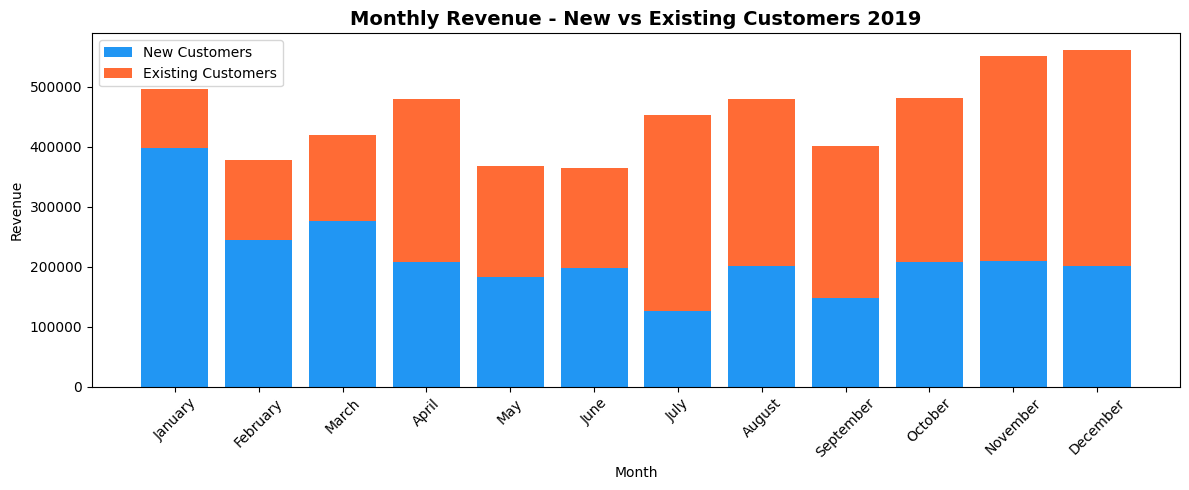

In [23]:
# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(revenue_pivot['Month_Name'], revenue_pivot['New'],
       label='New Customers', color='#2196F3')
ax.bar(revenue_pivot['Month_Name'], revenue_pivot['Existing'],
       bottom=revenue_pivot['New'],
       label='Existing Customers', color='#FF6B35')

ax.set_title('Monthly Revenue - New vs Existing Customers 2019',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analysis:
Revenue contribution shifts dramatically from new to existing customers across 2019. In January, new customers drive 80% of revenue as the customer base is just being established. By April, existing customers take over and dominate for the rest of the year - peaking at 72% in July.

This inverse relationship mirrors the acquisition vs retention pattern seen in Q2 and Q3 - H1 builds the customer base, H2 monetises it.

What this suggests about acquisition vs retention balance:


*   The business is currently over-indexed on acquisition in H1 and retention in H2 - a more balanced year-round approach would smooth
revenue fluctuations
*   Existing customers are the backbone of H2 revenue - investing in loyalty programs and repeat purchase incentives will protect this
revenue stream
*   New customer revenue drops sharply after January - acquisition campaigns need to be sustained through Q2 and Q3, not just Q1



#Q:6 -Analyze the relationship between coupon usage and revenue generation. How can discount strategies be optimized to maximize revenue while maintaining profitability?

In [83]:
# ============================================================
# Q6: Coupon Usage vs Revenue
# ============================================================

coupon_revenue = (
    df.groupby('Coupon_Status').agg(
        Transaction_Count= ('Transaction_ID', 'count'),
        Total_Revenue= ('Revenue', 'sum'),
        Avg_Revenue= ('Revenue', 'mean')
    ).reset_index().round(2)
)

coupon_revenue['Revenue_%']= (
    coupon_revenue['Total_Revenue'] / coupon_revenue['Total_Revenue'].sum() * 100
).round(1)


display(coupon_revenue)

# Monthly Coupon Usage vs Revenue
monthly_coupon= (df.groupby(['Month_Number','Month_Name','Coupon_Status'])['Revenue'].sum()
.reset_index()
.sort_values(['Month_Number','Coupon_Status'])
.round(2))
#display(monthly_coupon)

# Pivot
coupon_pivot= monthly_coupon.pivot(
    index=['Month_Number','Month_Name'],
    columns='Coupon_Status',
    values='Revenue'
).reset_index().fillna(0)

coupon_pivot.columns.name= None

display(coupon_pivot)

,Coupon_Status,Transaction_Count,Total_Revenue,Avg_Revenue,Revenue_%
0,Clicked,26926,2925740.61,108.66,53.9
1,Not Used,8094,897319.84,110.86,16.5
2,Used,17904,1608142.71,89.82,29.6


,Month_Number,Month_Name,Clicked,Not Used,Used
0,1,January,268695.75,74678.43,152168.70
1,2,February,208539.74,62724.19,106179.19
2,3,March,228363.19,73969.61,116906.46
3,4,April,252533.17,72817.24,153770.36
4,5,May,207335.29,58817.37,101737.71
5,6,June,193645.13,70314.16,100874.48
6,7,July,238804.19,75146.37,139327.00
7,8,August,250811.02,79363.84,148652.29
8,9,September,211800.62,67354.83,121679.34
9,10,October,257798.61,74070.71,150241.06


# Analysis:
Coupon usage analysis reveals a interesting pattern - transactions where coupons were Used generate the lowest average revenue (89.82) compared to Clicked (108.66) and Not Used (110.86). Despite being offered discounts, coupon users spend less per transaction, suggesting coupons attract lower-value purchases rather than driving premium spending.

"Clicked" transactions - where customers saw but didn't use the coupon - contribute the highest revenue share (53.9%), indicating a large segment of customers purchases at full price regardless of discount availability.

Strategies to optimise discount strategy:


*   Shift from blanket discounts to minimum order value coupons (e.g. "10% off orders above 500") to protect average order value
*   Target coupon campaigns specifically at low-tenure or inactive customers rather than all customers - high-value customers don't need discount incentives to purchase
*   Reduce coupon depth (currently 10-30%) for premium categories like Nest-USA where customers already demonstrate willingness to pay full price
*   Use "Clicked but not Used" segment for retargeting - these customers showed interest but purchased anyway, making them ideal candidates for loyalty rewards instead of discounts



#Q:7 -Identify the top-performing products and analyze the factors driving their success. How can this insight inform inventory management and promotional strategies?

In [25]:
# ============================================================
# Q7: Top Performing Products
# ============================================================
# Top 10 products by revenue

top_products_revenue = df.groupby(['Product_SKU', 'Product_Description', 'Product_Category']).agg(
    Total_Revenue= ('Revenue', 'sum'),
    Transaction_Count= ('Transaction_ID', 'count'),
    Avg_Revenue= ('Revenue', 'mean'),
    Total_Quantity= ('Quantity', 'sum')
).reset_index().sort_values('Total_Revenue', ascending=False).round(2).head(5).reset_index(drop=True)

print('Top Products by REvenue:')
display(top_products_revenue)

# Top 10 products by transaction count
top_products_count= df.groupby(['Product_SKU', 'Product_Description', 'Product_Category']).agg(
    Transaction_Count= ('Transaction_ID', 'count'),
    Total_Revenue= ('Revenue', 'sum'),
    Total_Quantity= ('Quantity', 'sum')
).reset_index().sort_values('Transaction_Count', ascending=False).round(2).head(5).reset_index(drop=True)

print('Top Products by Transaction Count:')
display(top_products_count)

# Top categories by revenue
top_categories= df.groupby('Product_Category').agg(
    Total_Revenue= ('Revenue', 'sum'),
    Transaction_Count= ('Transaction_ID', 'count'),
    Avg_Revenue= ('Revenue', 'mean')
).reset_index().sort_values('Total_Revenue', ascending=False).round(2).head(5).reset_index(drop=True)
print('Top Categories by Revenue:')
display(top_categories)

Top Products by REvenue:


,Product_SKU,Product_Description,Product_Category,Total_Revenue,Transaction_Count,Avg_Revenue,Total_Quantity
0,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,Nest-USA,736497.13,3511,209.77,4570
1,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,675772.58,3328,203.06,5206
2,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,571194.21,3230,176.84,4402
3,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,230435.53,1361,169.31,2683
4,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,226725.58,1065,212.89,2670


Top Products by Transaction Count:


,Product_SKU,Product_Description,Product_Category,Transaction_Count,Total_Revenue,Total_Quantity
0,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,Nest-USA,3511,736497.13,4570
1,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,3328,675772.58,5206
2,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,3230,571194.21,4402
3,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,1361,230435.53,2683
4,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1089,217442.02,1368


Top Categories by Revenue:


,Product_Category,Total_Revenue,Transaction_Count,Avg_Revenue
0,Nest-USA,2738702.08,14013,195.44
1,Apparel,834940.00,18126,46.06
2,Nest,522536.59,2198,237.73
3,Office,383853.84,6513,58.94
4,Drinkware,274809.08,3483,78.90


In [84]:
print(f"Total Transactions: {df['Transaction_ID'].count():,}")
print(f"Nest-USA Transactions: {df[df['Product_Category']=='Nest-USA']['Transaction_ID'].count():,}")
print(f"Nest-USA Transaction %: {df[df['Product_Category']=='Nest-USA']['Transaction_ID'].count()
/ df['Transaction_ID'].count() * 100:.1f}%")
print(f"Nest-USA Revenue %: {df[df['Product_Category']=='Nest-USA']['Revenue'].sum()
 / df['Revenue'].sum() * 100:.1f}%")

Total Transactions: 52,924
Nest-USA Transactions: 14,013
Nest-USA Transaction %: 26.5%
Nest-USA Revenue %: 50.4%


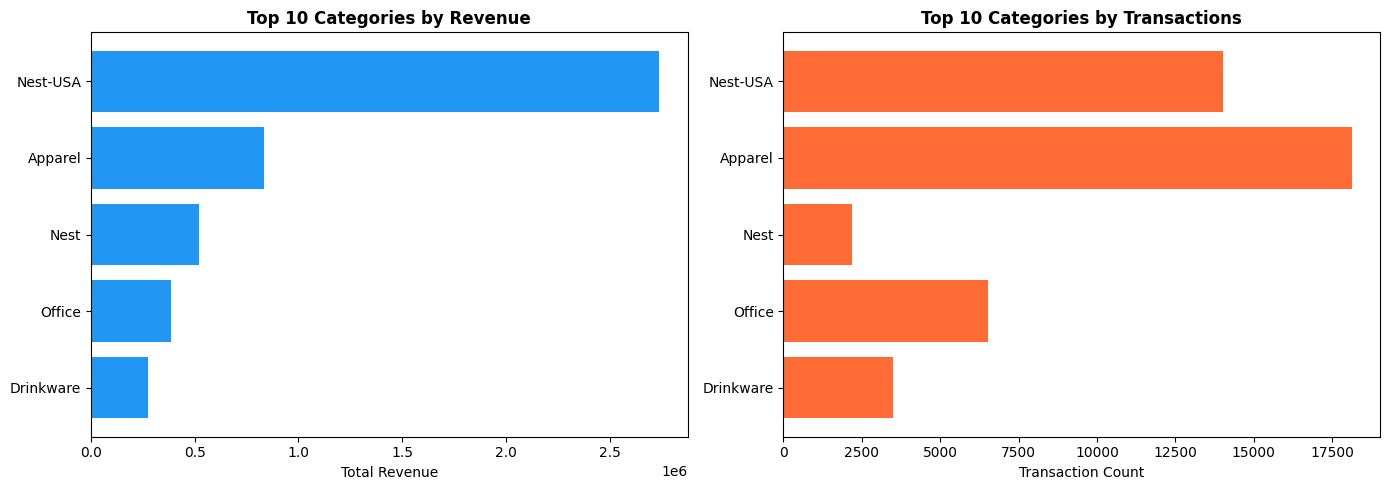

In [27]:
# Visualise top 10 categories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Revenue by category
top_cat_10 = top_categories.head(10)
axes[0].barh(top_cat_10['Product_Category'],
             top_cat_10['Total_Revenue'],
             color='#2196F3')
axes[0].set_title('Top 10 Categories by Revenue', fontweight='bold')
axes[0].set_xlabel('Total Revenue')
axes[0].invert_yaxis()

# Chart 2 - Transaction count by category
axes[1].barh(top_cat_10['Product_Category'],
             top_cat_10['Transaction_Count'],
             color='#FF6B35')
axes[1].set_title('Top 10 Categories by Transactions', fontweight='bold')
axes[1].set_xlabel('Transaction Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Analysis:
Nest-USA dominates both revenue and transaction rankings - the top 5 products by revenue are all Nest devices, contributing alomost 50% of total annual revenue (27.4L) despite accounting for only 26% of transactions.

Apparel leads in transaction volume (18,126) but generates significantly lower average revenue per transaction (46 vs 195 for Nest-USA), highlighting a clear distinction between high-frequency low-value and low-frequency high-value product segments.

Inventory & promotional strategy implications:
*   Prioritise Nest-USA stock availability year-round - any stockout directly impacts 50% of revenue
*   Avoid deep discounts on Nest products - customers are already paying premium prices willingly (avg 195/transaction)
*   Use Apparel as a traffic driver - its high transaction volume makes it ideal for attracting customers who may then cross-sell
into higher value Nest purchases
*   Further investigation needed on the standalone "Nest" category (5.2L, avg 237) - it has the highest average revenue per transaction and may be
an underutilised premium segment worth promoting more aggressively

#Q:8 -Analyze the relationship between monthly marketing spend and revenue. Are there any months where marketing efforts yielded disproportionately high or low returns? How can marketing strategies be adjusted to improve ROI?

In [28]:
# ============================================================
# Q8: Marketing Spend vs Revenue - ROI Analysis
# ============================================================
monthly_total_revenue= df.groupby(['Month_Number','Month_Name'])['Revenue'].sum().reset_index().round(2)
#display(monthly_total_revenue )

# Convert 'Date' column to datetime type
marketing['Date'] = pd.to_datetime(marketing['Date'])

# Monthly marketing spend
monthly_marketing= marketing.groupby(marketing['Date'].dt.month).agg(
    Offline_Spend=('Offline_Spend','sum'),
    Online_Spend=('Online_Spend', 'sum')
).reset_index().rename(columns={'Date': 'Month_Number'})

monthly_marketing['Total_Spend']= (
    monthly_marketing['Offline_Spend'] + monthly_marketing['Online_Spend']
).round(2)

#display(monthly_marketing)

# Merge the tables
roi_df = monthly_total_revenue.merge(
    monthly_marketing,
    on='Month_Number',
    how= 'left'
)

roi_df['ROI'] = (roi_df['Revenue'] / roi_df['Total_Spend']).round(2)
roi_df['ROI_%'] =(
    (roi_df['Revenue'] - roi_df['Total_Spend']) / roi_df['Total_Spend'] * 100).round(1)

display(roi_df)

,Month_Number,Month_Name,Revenue,Offline_Spend,Online_Spend,Total_Spend,ROI,ROI_%
0,1,January,495542.88,96600,58328.95,154928.95,3.20,219.9
1,2,February,377443.12,81300,55807.92,137107.92,2.75,175.3
2,3,March,419239.26,73500,48750.09,122250.09,3.43,242.9
3,4,April,479120.77,96000,61026.83,157026.83,3.05,205.1
4,5,May,367890.37,65500,52759.64,118259.64,3.11,211.1
5,6,June,364833.77,80500,53818.14,134318.14,2.72,171.6
6,7,July,453277.56,67500,52717.85,120217.85,3.77,277.0
7,8,August,478827.15,85500,57404.15,142904.15,3.35,235.1
8,9,September,400834.79,83000,52514.54,135514.54,2.96,195.8
9,10,October,482110.38,93500,57724.65,151224.65,3.19,218.8


# Plotting

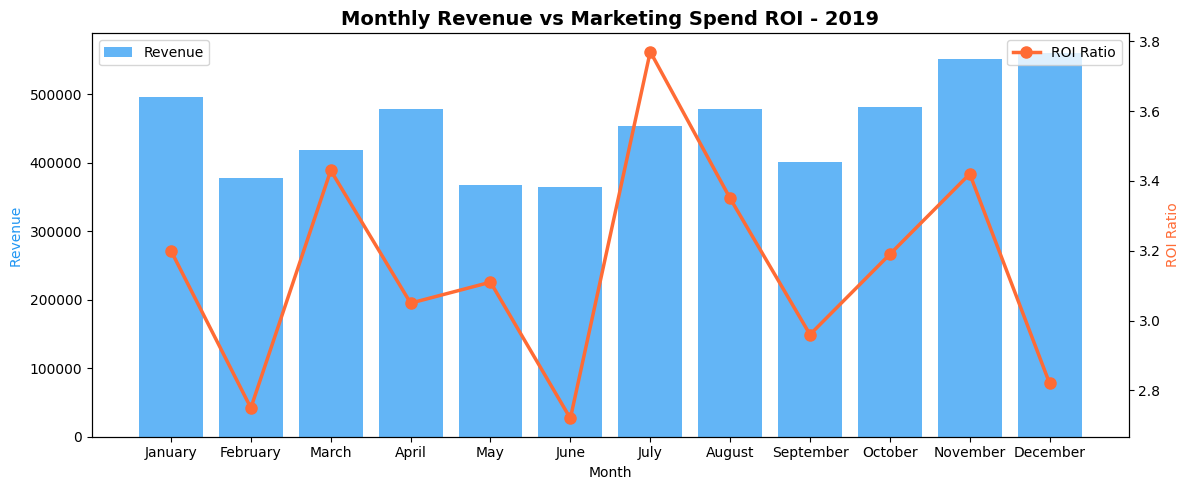

In [29]:
# Visualisation
fig, ax1 = plt.subplots(figsize=(12, 5))

ax2 = ax1.twinx()

ax1.bar(roi_df['Month_Name'], roi_df['Revenue'],
        color='#2196F3', alpha=0.7, label='Revenue')
ax2.plot(roi_df['Month_Name'], roi_df['ROI'],
         color='#FF6B35', marker='o', linewidth=2.5,
         markersize=8, label='ROI Ratio')

ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue ', color='#2196F3')
ax2.set_ylabel('ROI Ratio', color='#FF6B35')
ax1.set_title('Monthly Revenue vs Marketing Spend ROI - 2019',
              fontsize=14, fontweight='bold')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analysis:
July delivers the highest marketing ROI (3.77x) with one of the lowest spends (1.20L), while December the highest spend month (1.99L) yields only 2.82x ROI despite generating peak revenue. This suggests December revenue is driven by seasonal demand rather than marketing effectiveness, meaning current spend levels in Q4 may be inefficient.

March and November also deliver strong ROI (3.43x and 3.42x respectively)at moderate spend levels, indicating these are the most efficient marketing months of the year.

How to adjust marketing strategy:
*   Increase spend in July, March and November where ROI is highest these months convert marketing investment most efficiently
*   Cap December spend growth as seasonal demand will drive revenue anyways. marginal spend beyond a threshold will yield diminishing returns
*   Audit June and February campaigns where ROI is weakest despite moderate spend, also identify underperforming channels
*   Set up a ROI benchmark of 3, any month falling behind should raise a flag for review

# Q:9 -Evaluate the effectiveness of marketing campaigns by comparing marketing spend to revenue generated. Are there opportunities to reallocate resources for better results?

In [30]:
# ============================================================
# Q9: Marketing Channel Effectiveness - Offline vs Online
# ============================================================

# Monthly channel breakdown already in roi_df
# Calculate channel-wise ROI contribution

# Total spent by channel
total_offline = roi_df['Offline_Spend'].sum()
total_online = roi_df['Online_Spend'].sum()
total_revenue = roi_df['Revenue'].sum()

print("=== Overall Channel Summary ===")
print(f"Total Offline Spend: {total_offline:,.2f}")
print(f"Total Online Spend: {total_online:,.2f}")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Offline Spend %: {total_offline /(total_offline + total_online)*100:.1f}")
print(f"Online Spend %: {total_online /(total_offline + total_online)*100:.1f}")


=== Overall Channel Summary ===
Total Offline Spend: 1,037,900.00
Total Online Spend: 695,646.47
Total Revenue: 5,431,203.16
Offline Spend %: 59.9
Online Spend %: 40.1


#  Plot Monthly offline vs online spend trend

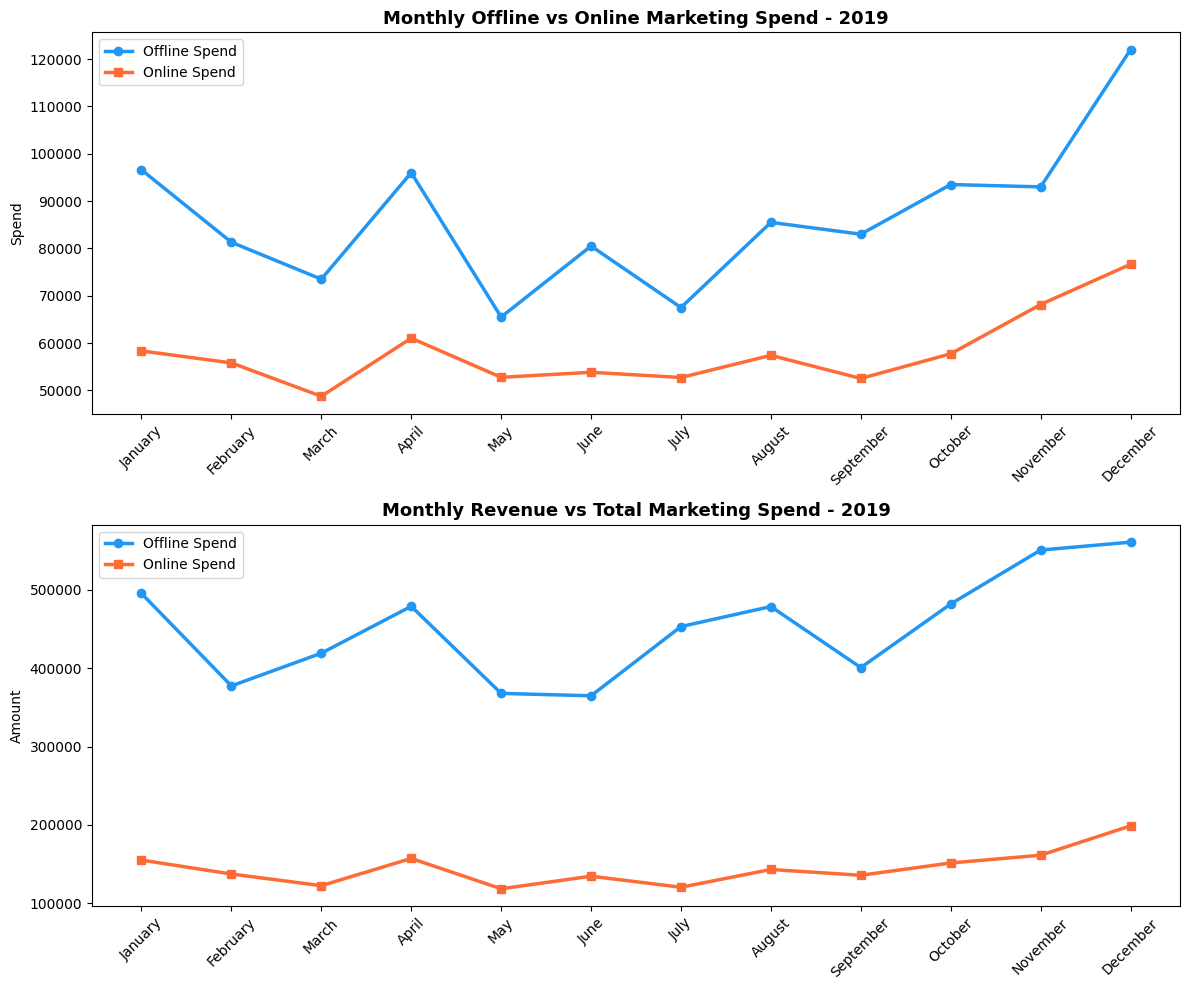

In [31]:
# Monthly offline vs online spend trend
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Chart 1 - Spend by channel
axes[0].plot(roi_df['Month_Name'], roi_df['Offline_Spend'],
             marker='o', linewidth=2.5, color='#2196F3',
             label='Offline Spend', markersize=6
             )
axes[0].plot(roi_df['Month_Name'], roi_df['Online_Spend'],
             marker='s', linewidth=2.5, color='#FF6B35',
             label='Online Spend', markersize=6)

axes[0].set_title('Monthly Offline vs Online Marketing Spend - 2019',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Spend')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)


# Chart 2 - Revenue vs Total Spend
axes[1].plot(roi_df['Month_Name'], roi_df['Revenue'],
             marker='o', linewidth=2.5, color='#2196F3',
             label='Offline Spend', markersize=6
             )
axes[1].plot(roi_df['Month_Name'], roi_df['Total_Spend'],
             marker='s', linewidth=2.5, color='#FF6B35',
             label='Online Spend', markersize=6)

axes[1].set_title('Monthly Revenue vs Total Marketing Spend - 2019',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [32]:
# Reallocation opportunities
print("\n=== Reallocation Opportunities ===")
print("High ROI months (above 3.3x) - Increase spend:")
display(roi_df[roi_df['ROI'] >= 3.3][['Month_Name', 'Total_Spend', 'Revenue', 'ROI']].reset_index(drop=True))

print("\nLow ROI months (below 3.0x) - Review spend:")
display(roi_df[roi_df['ROI'] < 3.0][['Month_Name', 'Total_Spend', 'Revenue', 'ROI']].reset_index(drop=True))


=== Reallocation Opportunities ===
High ROI months (above 3.3x) - Increase spend:


,Month_Name,Total_Spend,Revenue,ROI
0,March,122250.09,419239.26,3.43
1,July,120217.85,453277.56,3.77
2,August,142904.15,478827.15,3.35
3,November,161144.96,550994.61,3.42



Low ROI months (below 3.0x) - Review spend:


,Month_Name,Total_Spend,Revenue,ROI
0,February,137107.92,377443.12,2.75
1,June,134318.14,364833.77,2.72
2,September,135514.54,400834.79,2.96
3,December,198648.75,561088.50,2.82


# Analysis:
Total marketing spend of 17.3L is split 60% offline and 40% online. Without channel-level revenue attribution, direct ROI by channel cannot be calculated.

Four months -March, July, August, November -consistently deliver ROI above 3.3x at moderate spend levels, while four months -February, June, September, December -fall below 3.0x despite comparable or higher spend.

Reallocation opportunities:
*  Reallocate 30-40K from December (2.82x ROI, highest spend) to July and March where the same spend generates 35-40% better returns
*  Shift offline budget proportion toward online in low-ROI months -online channels offer better targeting and measurability to diagnose why February and June underperform
*  Set a minimum 3.0x ROI threshold as a performance benchmark - months falling below should trigger a channel mix audit
*  Currently offline and online spend cannot be evaluated independently, limiting optimization precision, introduce some new mechanism to track these metrics(Like introducing some code for Online and Offline spend to track them)

# Q:10 -Segment customers into groups such as Premium, Gold, Silver, and Standard. What targeted strategies can be developed for each segment to improve retention and revenue? (Use RFM segmentation techniques)

In [33]:
# ============================================================
# Q10: RFM Segmentation
# ============================================================

# Reference date = day after last transaction in dataset

reference_date = df['Transaction_Date'].max() + pd.Timedelta(days=1)
print(f"Reference Date: {reference_date}")

#  Calculate R, F, M per customer(Recency,Frequency,Monetary)
rfm= df.groupby('CustomerID').agg(
    Recency=('Transaction_Date', lambda x: (reference_date - x.max()).days),
    Frequency=('Transaction_ID', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index().round(2)

print("\nRFM Stats:")
#display(rfm.describe().T.round(2))
display(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

Reference Date: 2020-01-01 00:00:00

RFM Stats:


,Recency,Frequency,Monetary
count,1468.00,1468.00,1468.00
mean,145.29,18.14,3699.73
std,101.94,24.98,5880.24
min,1.00,1.00,7.00
25%,56.00,5.00,787.82
50%,132.00,11.00,2029.47
75%,221.00,23.00,4520.97
max,365.00,328.00,87699.62


In [34]:
# Score each dimension 1-4 using quartiles
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],q=4,labels=[4,3,2,1] # lower recency = better
)

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=4,
                          labels=[1, 2, 3, 4])  # higher frequency = better

rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),
                          q=4,
                          labels=[1, 2, 3, 4])  # higher monetary = better

# Total RFM Score
rfm['RFM_Score'] = (rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int))

# Assign Segments
def assign_segment(score):
  if score >= 10:
    return 'Premium'
  elif score >= 7:
    return 'Gold'
  elif score >= 5:
    return 'Silver'
  else:
    return 'Standard'
rfm['Segment'] = rfm['RFM_Score'].apply(assign_segment)
#display(rfm)

# SEgment Summary
segment_summary= rfm.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency= ('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).reset_index().round(2)

segment_summary['Revenue_%'] = (
    segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum()*100
).round(2)

display(segment_summary)

,Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_%
0,Gold,484,147.91,15.77,3157.03,1528003.32,28.13
1,Premium,408,63.41,40.27,8503.24,3469321.36,63.88
2,Silver,338,172.34,5.76,1013.24,342476.25,6.31
3,Standard,238,241.94,2.60,384.04,91402.23,1.68


# Plot the Data

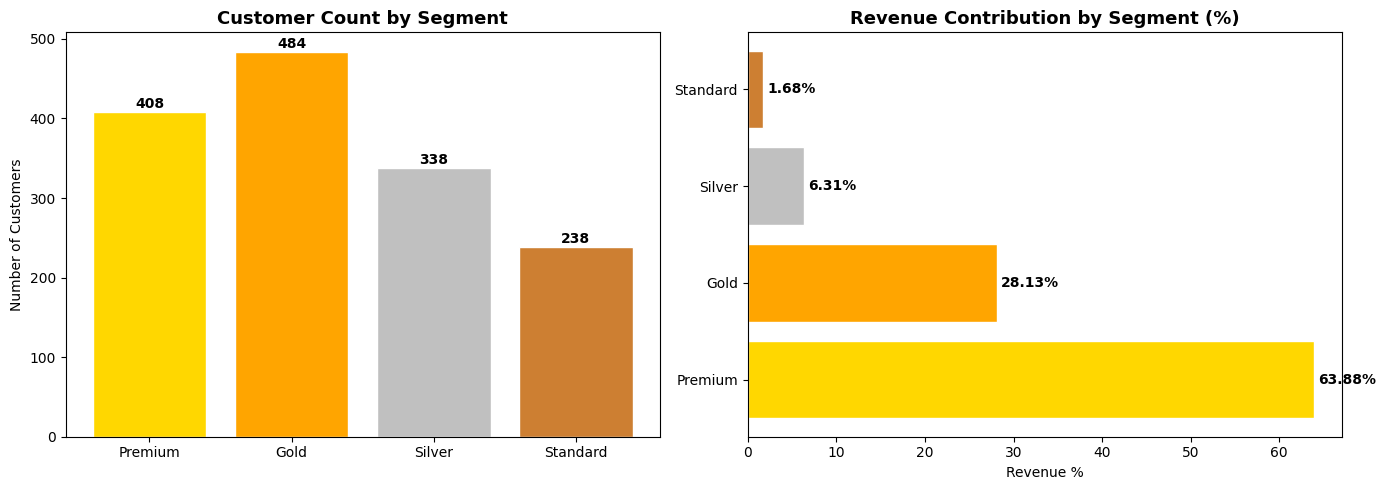

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Customer count by segment
segment_order = ['Premium', 'Gold', 'Silver', 'Standard']
colors = ['#FFD700', '#FFA500', '#C0C0C0', '#CD7F32']

sorted_summary = segment_summary.set_index('Segment').loc[segment_order].reset_index()

axes[0].bar(sorted_summary['Segment'],
            sorted_summary['Customer_Count'],
            color=colors, edgecolor='white')
axes[0].set_title('Customer Count by Segment',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')

for bar, val in zip(axes[0].patches,
                    sorted_summary['Customer_Count']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 str(int(val)),
                 ha='center', fontweight='bold')

# Chart 2 - Revenue % by segment (horizontal bar instead of pie)
axes[1].barh(sorted_summary['Segment'],
             sorted_summary['Revenue_%'],
             color=colors, edgecolor='white')
axes[1].set_title('Revenue Contribution by Segment (%)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Revenue %')

for bar, val in zip(axes[1].patches,
                    sorted_summary['Revenue_%']):
    axes[1].text(bar.get_width() + 0.5,
                 bar.get_y() + bar.get_height()/2,
                 f'{val}%',
                 va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### RFM Segmentation Analysis

RFM segmentation reveals a **highly skewed revenue distribution**. **Premium customers** (408, 27.8% of total) contribute **63.9% of total revenue** with an average spend of 8,503 and 40 purchases per year – indicating a highly engaged, high-value core base.

In contrast, **Standard customers** (238, 16.2% of total) contribute **only 1.7% of revenue**, averaging just 2.6 purchases and 384 spend, with a recency of 242 days suggesting they are largely inactive.

### Targeted Strategies by Segment:

*   **Premium Customers (408 customers - Protect at all costs):**
    *   Dedicated account management and exclusive early access to new products.
    *   VIP loyalty rewards and personalized thank-you offers.
    *   Avoid discounts – they buy frequently at full price already.

*   **Gold Customers (484 customers - Grow into Premium):**
    *   Targeted upsell campaigns on Nest-USA products to increase order value.
    *   Frequency nudges – "You haven't shopped in X days" reminder emails.
    *   Milestone rewards when they cross the Premium spend threshold.

*   **Silver Customers (338 customers - Activate more):**
    *   Category-specific promotions on their most purchased categories.
    *   Bundle offers to increase average order value above current $1,013.
    *   Re-engagement campaigns targeting their 172-day average recency.

*   **Standard Customers (238 customers - Re-engage or Accept Churn):**
    *   Win-back campaigns with strong first-purchase incentives.
    *   Survey to understand why they went inactive after 242 days.
    *   If unresponsive after 2 campaigns, redirect budget to Gold/Silver segments.

# Q:11 -Analyze the revenue contribution of each customer segment. How can the company focus its efforts on high-value segments while nurturing lower-value segments?

In [36]:
# ============================================================
# Q11: Revenue Contribution by Customer Segment
# ============================================================

# Drop Segment column if it already exists
df = df.drop(columns=[col for col in df.columns if 'Segment' in col])

# Merge Segment into df
df = df.merge(
    rfm[['CustomerID','Segment']],
    on='CustomerID',
    how='left'
)

#display(df.head(3))

# Revenue Per Customer by segment
segment_revenue= segment_summary[['Segment', 'Customer_Count','Total_Revenue', 'Revenue_%']].copy()
segment_revenue['Revenue_Per_Customer'] = (segment_revenue['Total_Revenue'] / segment_revenue['Customer_Count']).round(2)
display(segment_revenue)





,Segment,Customer_Count,Total_Revenue,Revenue_%,Revenue_Per_Customer
0,Gold,484,1528003.32,28.13,3157.03
1,Premium,408,3469321.36,63.88,8503.24
2,Silver,338,342476.25,6.31,1013.24
3,Standard,238,91402.23,1.68,384.04


In [37]:
# Top 3 categories per segment
category_segment= (
    df.groupby(['Segment', 'Product_Category'])['Revenue'].sum().reset_index()
    .sort_values(['Segment','Revenue'], ascending=[True,False])
)

#display(category_segment)

print("\nTop 3 Categories per Segment:")
for segment in ['Premium', 'Gold', 'Silver', 'Standard']:
  print(f"\n{segment:}")
  display(category_segment[category_segment['Segment'] == segment].head(3).reset_index(drop=True))


Top 3 Categories per Segment:

Premium


,Segment,Product_Category,Revenue
0,Premium,Nest-USA,1716869.72
1,Premium,Apparel,497209.36
2,Premium,Nest,439160.50



Gold


,Segment,Product_Category,Revenue
0,Gold,Nest-USA,802525.06
1,Gold,Apparel,243522.60
2,Gold,Office,125698.75



Silver


,Segment,Product_Category,Revenue
0,Silver,Nest-USA,178458.59
1,Silver,Apparel,70532.72
2,Silver,Office,24490.85



Standard


,Segment,Product_Category,Revenue
0,Standard,Nest-USA,40848.71
1,Standard,Apparel,23675.32
2,Standard,Office,7274.24


In [88]:
# Monthly revenue trend by segment
monthly_segment = (
    df.groupby(['Month_Number', 'Month_Name', 'Segment'])['Revenue'].sum()
    .reset_index().sort_values('Month_Number').round(2)
)
#display(monthly_segment)

segment_pivot=monthly_segment.pivot(
    index=['Month_Number', 'Month_Name'],
    columns='Segment',
    values= 'Revenue'
).reset_index().fillna(0)
segment_pivot.columns.name= None

display(segment_pivot)

,Month_Number,Month_Name,Gold,Premium,Silver,Standard
0,1,January,240798.13,168537.57,67339.54,18867.64
1,2,February,179502.82,186565.06,6704.15,4671.09
2,3,March,159390.08,204374.93,38442.80,17031.45
3,4,April,140630.18,262851.79,55622.15,20016.65
4,5,May,135378.59,197662.68,25107.40,9741.70
5,6,June,107354.69,207472.26,43547.19,6459.63
6,7,July,70314.79,348735.93,25283.91,8942.93
7,8,August,150987.57,284598.33,37570.11,5671.14
8,9,September,94561.14,292520.92,13752.73,0.00
9,10,October,122105.20,343919.36,16085.82,0.00


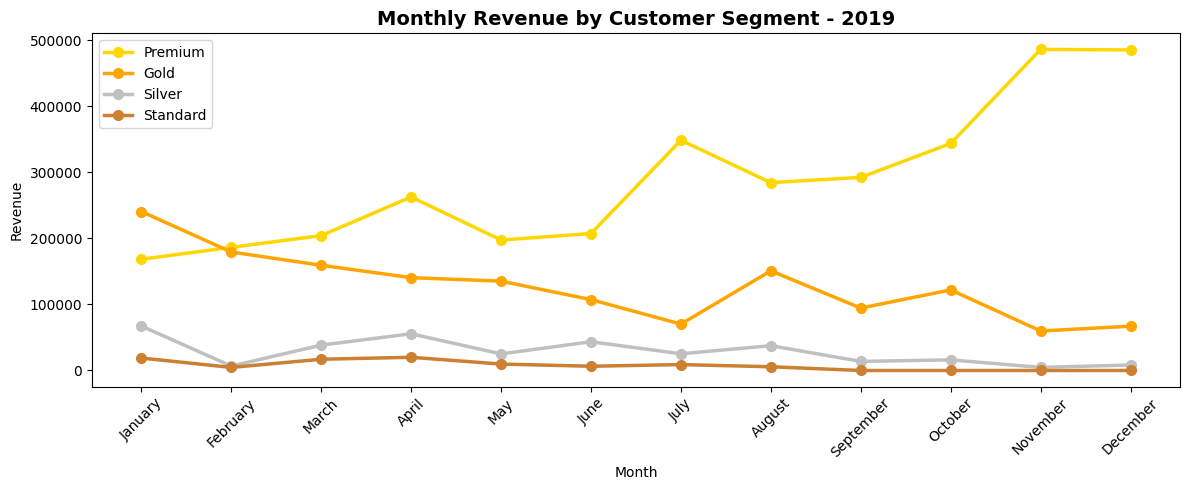

In [39]:
# Visualise
fig, ax = plt.subplots(figsize=(12, 5))
colors = {'Premium': '#FFD700',
          'Gold': '#FFA500',
          'Silver': '#C0C0C0',
          'Standard': '#CD7F32'}

for segment in ['Premium', 'Gold', 'Silver', 'Standard']:
    if segment in segment_pivot.columns:
        ax.plot(segment_pivot['Month_Name'],
                segment_pivot[segment],
                marker='o', linewidth=2.5,
                label=segment,
                color=colors[segment],
                markersize=7)

ax.set_title('Monthly Revenue by Customer Segment - 2019',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analysis:

Revenue contribution is heavily concentrated in the Premium segment (63.9%), which grows consistently through 2019 - from 1.68L in January to 4.86L in November, a 3x increase. This confirms Premium customers become more engaged over time, not less.

Gold segment shows the opposite pattern - highest revenue in January (2.40L) declining to 59,850 by November, suggesting Gold customers are at risk of disengaging in H2 and may need targeted intervention to prevent downward migration to Silver.

Most concerning: Standard customers generated 0 revenue from September onwards - indicating near-complete churn in H2.

How to focus efforts:

###High-value (Premium) - protect and grow:
* Personalised year-round engagement to maintain 3x growth trajectory
* Early access to new Nest products which drive their highest spend

###Mid-value (Gold) - prevent H2 decline:
* Launch Gold-specific re-engagement campaigns from June onwards
* Milestone rewards to incentivise upgrade to Premium threshold

###Lower-value (Silver & Standard) - nurture selectively:
* Win-back campaigns for Standard customers before September cutoff
* Bundle promotions for Silver to increase order frequency
* Accept that Standard segment may not be worth heavy investment if unresponsive after 2 campaigns


#

# Q:12 -Group customers by their month of first purchase and analyze retention rates over time. Which cohorts exhibit the highest and lowest retention rates? What strategies can be implemented to improve retention for weaker cohorts?

In [40]:
# ============================================================
# Q12: Cohort Analysis
# ============================================================

# Get each customer's cohort (first purchase month)
cohort_df = df.copy()
cohort_df['Cohort_Month'] = cohort_df['Customer_Acquisition_Date'].dt.to_period('M')
cohort_df['Transaction_Month'] = cohort_df['Transaction_Date'].dt.to_period('M')

# Calculate months since first purchase
cohort_df['Month_Number_Cohort']= (cohort_df['Transaction_Month'] - cohort_df['Cohort_Month']).apply(lambda x: x.n)

display(cohort_df.head(3))

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month_Number,Month_Name,Retention_Period,Order_Value,Month_Abbr,Month,Discount_pct,GST,Gender,Location,Tenure_Months,Discount_Applied,Revenue,Customer_Acquisition_Date,Customer_Type,Segment,Cohort_Month,Transaction_Month,Month_Number_Cohort
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,Nest-USA,1,153.71,6.5,Used,1,January,Low Retention,153.71,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,160.21,2019-01-01,New,Gold,2019-01,2019-01,0
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,Nest-USA,1,153.71,6.5,Used,1,January,Low Retention,153.71,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,160.21,2019-01-01,New,Gold,2019-01,2019-01,0
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,January,Low Retention,2.05,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,8.55,2019-01-01,New,Gold,2019-01,2019-01,0


In [41]:
# Count unique customers per cohort per month
cohort_counts = cohort_df.groupby(['Cohort_Month', 'Month_Number_Cohort'])['CustomerID'].nunique().reset_index()
#display(cohort_counts)
cohort_pivot = cohort_counts.pivot(
    index='Cohort_Month',
    columns= 'Month_Number_Cohort',
    values= 'CustomerID'
)
display(cohort_pivot)

Month_Number_Cohort,0,1,2,3,4,5,6,7,8,9,10,11
Cohort_Month,,,,,,,,,,,,
2019-01,215.0,13.0,24.0,34.0,23.0,44.0,35.0,47.0,23.0,28.0,20.0,34.0
2019-02,96.0,7.0,9.0,16.0,17.0,22.0,19.0,15.0,12.0,11.0,16.0,NaN
2019-03,177.0,18.0,35.0,25.0,32.0,33.0,22.0,22.0,15.0,19.0,NaN,NaN
2019-04,163.0,14.0,24.0,24.0,18.0,15.0,10.0,16.0,12.0,NaN,NaN,NaN
2019-05,112.0,12.0,9.0,13.0,10.0,13.0,14.0,8.0,NaN,NaN,NaN,NaN
2019-06,137.0,20.0,22.0,12.0,11.0,14.0,11.0,NaN,NaN,NaN,NaN,NaN
2019-07,94.0,13.0,4.0,6.0,11.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,135.0,14.0,15.0,10.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,78.0,6.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
# Calculate retention rates
cohort_size= cohort_pivot[0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

print("Cohort Size:")
display(cohort_size)

print("\nRetention Matrix (%):")
display(retention_matrix)

Cohort Size:


,0
Cohort_Month,
2019-01,215.0
2019-02,96.0
2019-03,177.0
2019-04,163.0
2019-05,112.0
2019-06,137.0
2019-07,94.0
2019-08,135.0
2019-09,78.0



Retention Matrix (%):


Month_Number_Cohort,0,1,2,3,4,5,6,7,8,9,10,11
Cohort_Month,,,,,,,,,,,,
2019-01,100.0,6.0,11.2,15.8,10.7,20.5,16.3,21.9,10.7,13.0,9.3,15.8
2019-02,100.0,7.3,9.4,16.7,17.7,22.9,19.8,15.6,12.5,11.5,16.7,NaN
2019-03,100.0,10.2,19.8,14.1,18.1,18.6,12.4,12.4,8.5,10.7,NaN,NaN
2019-04,100.0,8.6,14.7,14.7,11.0,9.2,6.1,9.8,7.4,NaN,NaN,NaN
2019-05,100.0,10.7,8.0,11.6,8.9,11.6,12.5,7.1,NaN,NaN,NaN,NaN
2019-06,100.0,14.6,16.1,8.8,8.0,10.2,8.0,NaN,NaN,NaN,NaN,NaN
2019-07,100.0,13.8,4.3,6.4,11.7,9.6,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,100.0,10.4,11.1,7.4,5.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,100.0,7.7,3.8,2.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


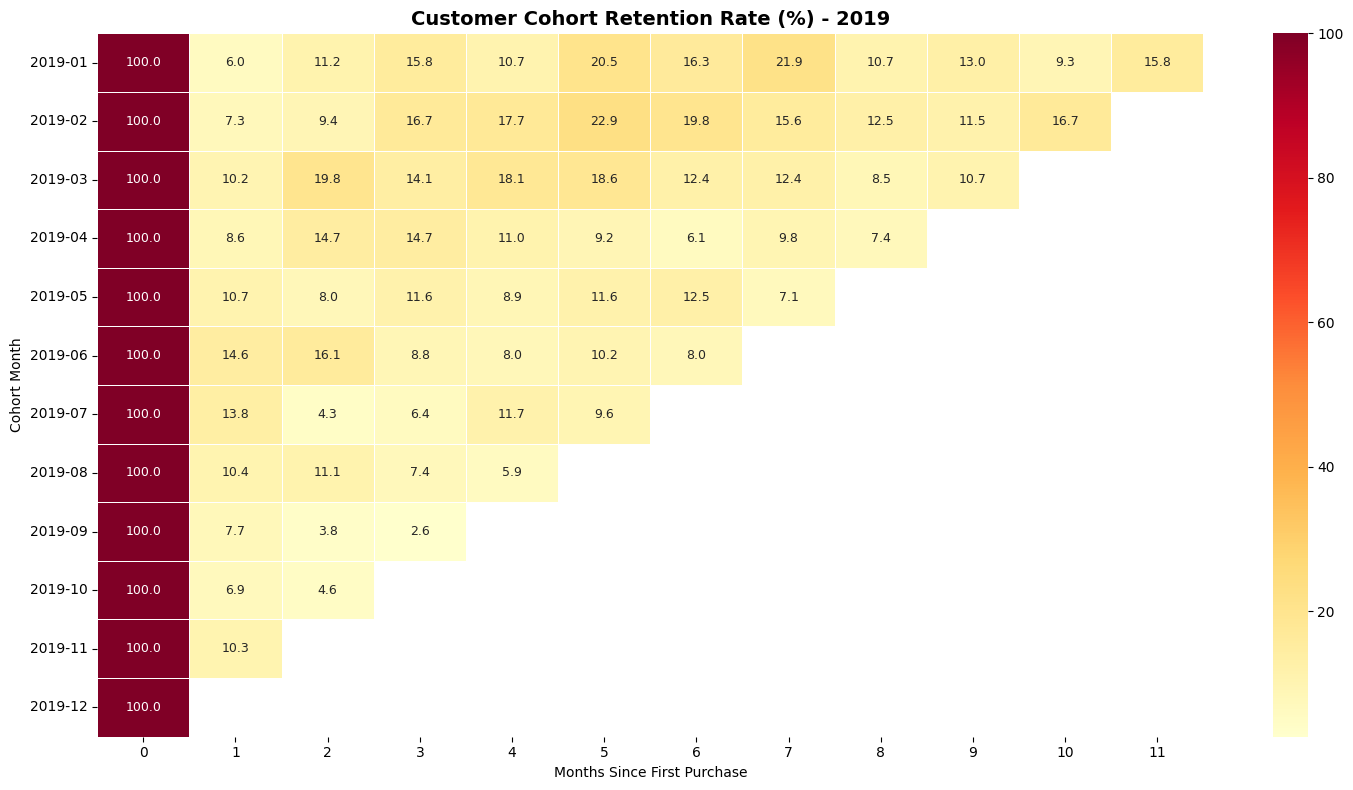

In [43]:
# Step 6: Heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Customer Cohort Retention Rate (%) - 2019',
          fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

# Analysis
Cohort analysis reveals a consistent purchase cycle pattern across all 2019 cohorts. Month 1 retention is universally low (6-14%),but retention peaks around Month 5 for early cohorts - February cohort peaks at 22.9% in Month 5, January at 20.5% - suggesting customers operate on a ~5 month repurchase cycle rather than purchasing monthly.

Strongest cohorts: June (14.6% Month 1) and July (13.8% Month 1) show the best early retention, possibly driven by mid-year promotions.

Weakest cohorts: September and October drop sharply after Month 1 (3.8% and 4.6% by Month 2-3), indicating H2 acquired customers are
harder to retain - consistent with the H2 acquisition challenge identified in Q2.

###Strategies for weaker cohorts:
* Implement a Month 1 re-engagement trigger for all new customers - a targeted offer sent 30 days after first purchase to bridge the gap before the natural Month 5 return cycle
* For September and October cohorts specifically, launch win-back campaigns at Month 2 before retention drops below 4%
* Use June and July cohort behavior as a template - analyze what promotions or products drove their superior early retention and replicate in Q4 acquisition campaigns


# Q13-Analyze the lifetime value of customers acquired in different months. How can this insight inform acquisition and retention strategies?

In [44]:
# ============================================================
# Q13: Customer Lifetime Value by Acquisition Cohort
# ============================================================

# Total revenue per customer
customer_revenue= df.groupby('CustomerID')['Revenue'].sum().reset_index().rename(columns={'Revenue': 'CLV'}).round(2)
#display(customer_revenue)

# Merge with Acquisition Month
clv_df = customer_revenue.merge(
    first_purchase[['CustomerID', 'Customer_Acquisition_Date']],
    on= 'CustomerID',
    how= 'left'
)
clv_df['Acquisition_Month_Number']= clv_df['Customer_Acquisition_Date'].dt.month
clv_df['Acquisition_Month']= clv_df['Customer_Acquisition_Date'].dt.month_name()
#display(clv_df)

# CLV Cohort
cohort_clv= clv_df.groupby(['Acquisition_Month_Number','Acquisition_Month']).agg(
    Customer_Count=('CustomerID','count'),
    Total_CLV= ('CLV', 'sum'),
    Avg_CLV= ('CLV', 'mean'),
    Min_CLV= ('CLV','min'),
    Max_CLV= ('CLV', 'max')
).reset_index().sort_values('Acquisition_Month_Number').round(2)
display(cohort_clv)


,Acquisition_Month_Number,Acquisition_Month,Customer_Count,Total_CLV,Avg_CLV,Min_CLV,Max_CLV
0,1,January,215,1233778.36,5738.50,7.96,87699.62
1,2,February,96,640192.68,6668.67,80.37,30905.53
2,3,March,177,775465.63,4381.16,15.78,31951.56
3,4,April,163,525965.98,3226.79,15.57,22710.02
4,5,May,112,388806.64,3471.49,7.32,18969.44
5,6,June,137,335460.32,2448.62,20.07,13593.80
6,7,July,94,278996.75,2968.05,14.50,24034.89
7,8,August,135,304051.64,2252.23,9.29,20963.09
8,9,September,78,169951.53,2178.87,8.25,12589.63
9,10,October,87,271746.98,3123.53,7.00,13962.89


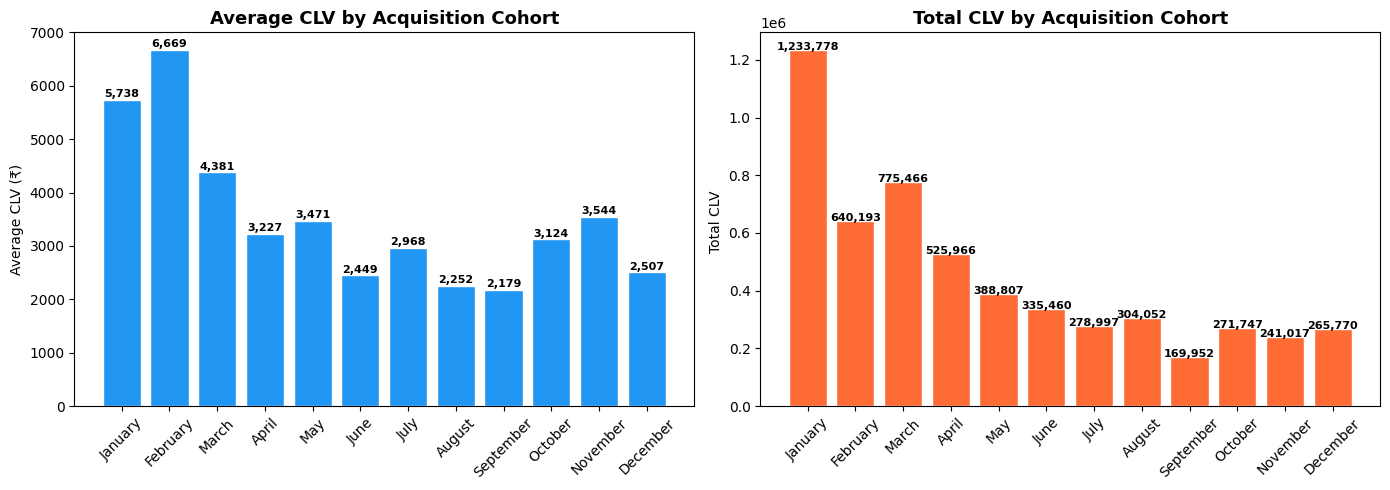

In [79]:
# Step 4: Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Average CLV by cohort
axes[0].bar(cohort_clv['Acquisition_Month'],
            cohort_clv['Avg_CLV'],
            color='#2196F3', edgecolor='white')
axes[0].set_title('Average CLV by Acquisition Cohort',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average CLV (₹)')
axes[0].tick_params(axis='x', rotation=45)

for bar, val in zip(axes[0].patches, cohort_clv['Avg_CLV']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{val:,.0f}',
                 ha='center', fontsize=8, fontweight='bold')

# Chart 2 - Total CLV by cohort
axes[1].bar(cohort_clv['Acquisition_Month'],
            cohort_clv['Total_CLV'],
            color='#FF6B35', edgecolor='white')
axes[1].set_title('Total CLV by Acquisition Cohort',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total CLV ')
axes[1].tick_params(axis='x', rotation=45)

for bar, val in zip(axes[1].patches, cohort_clv['Total_CLV']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{val:,.0f}',
                 ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Analysis
CLV analysis reveals a clear time-advantage effect - customers acquired earlier in the year generate significantly higher lifetime value due to having more months to transact. January cohort leads in Total CLV (12.3L) while February leads in Average CLV (6,668) despite being a smaller cohort - suggesting February acquired fewer but higher-quality
customers.

CLV declines progressively through H2, with September recording the lowest average CLV (2,178) - less than half of February's value.
This reinforces the importance of early-year acquisition.

How this informs acquisition and retention strategy:
###Acquisition:
* Prioritise Q1 acquisition campaigns (January-March) where customers have maximum time to generate value - every month of earlier acquisition adds measurable CLV
* Focus February campaigns on quality over quantity - smaller cohort but higher average spend suggests better customer targeting in that month

###Retention:
* H2 acquired customers (July-December) have naturally lower CLV due to limited time - compensate with higher purchase frequency incentives to maximise their short remaining window
* September cohort (lowest CLV at 2,178) needs immediate aggressive re-engagement - a 30-day post-purchase trigger campaign could
  significantly improve their lifetime value

#Q14-Do customers who use coupons have a different average transaction value compared to those who do not?Conduct a statistical test to validate this hypothesis. What implications does this have for the company’s discount and coupon strategies?

In [91]:
# ============================================================
# Q14: Statistical Test - Coupon Users vs Non-Users
# ============================================================

coupon_used= df[df['Coupon_Status'] == 'Used']['Revenue']
#display(coupon_used)
coupon_not_used= df[df['Coupon_Status'] != 'Used']['Revenue']
#display(coupon_not_used)

print("=== Group Statistics ===")
print(f"Coupon Used    - Count: {len(coupon_used):,} | Mean: {coupon_used.mean():.2f}"
      f" | Std: {coupon_used.std():.2f}")
print(f"Coupon Not Used - Count: {len(coupon_not_used):,}"
      f" | Mean: {coupon_not_used.mean():.2f} | Std: {coupon_not_used.std():.2f}")

# Run T-Test
t_stat, p_value = stats.ttest_ind(coupon_used, coupon_not_used)

print("\n=== T-Test Results ===")
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.6f}")

# Interpret result
alpha = 0.05
print(f"\n=== Interpretation ===")
print(f"Significance Level (alpha) : {alpha}")
if p_value < alpha:
    print(f"P-value ({p_value:.6f}) < alpha ({alpha})")
    print("Result: REJECT H0 — Significant difference exists between groups")
    print("Coupon users and non-users have statistically different transaction values")
else:
    print(f"P-value ({p_value:.6f}) > alpha ({alpha})")
    print("Result: FAIL TO REJECT H0 — No significant difference between groups")

=== Group Statistics ===
Coupon Used    - Count: 17,904 | Mean: 89.82 | Std: 159.27
Coupon Not Used - Count: 35,020 | Mean: 109.17 | Std: 179.34

=== T-Test Results ===
T-Statistic : -12.1859
P-Value     : 0.000000

=== Interpretation ===
Significance Level (alpha) : 0.05
P-value (0.000000) < alpha (0.05)
Result: REJECT H0 — Significant difference exists between groups
Coupon users and non-users have statistically different transaction values


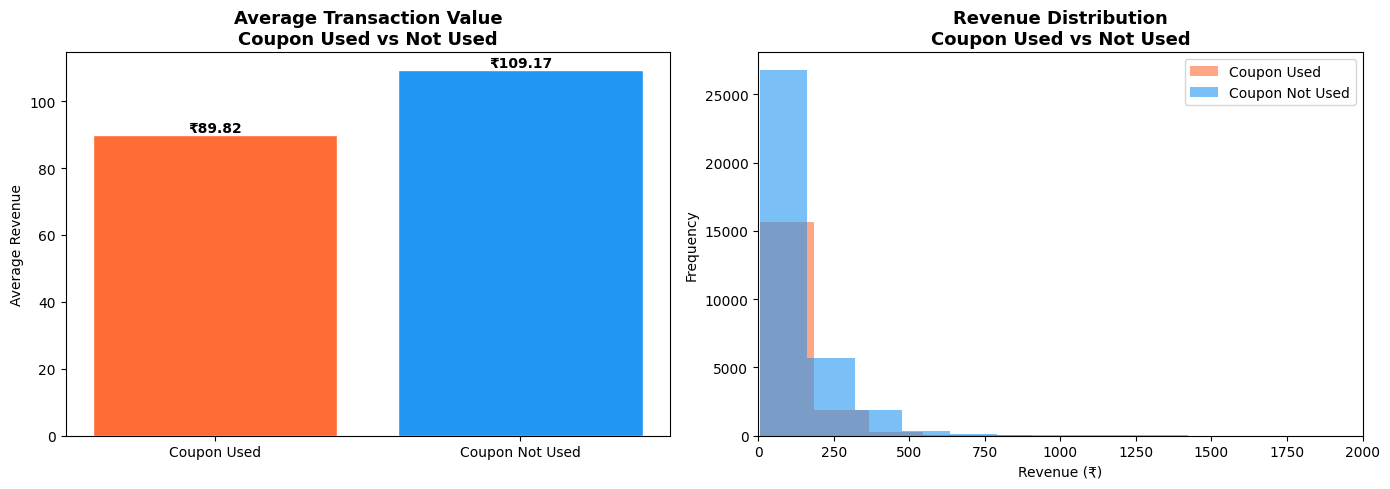

In [47]:
# Step 4: Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Average transaction value
groups = ['Coupon Used', 'Coupon Not Used']
means = [coupon_used.mean(), coupon_not_used.mean()]
colors = ['#FF6B35', '#2196F3']

axes[0].bar(groups, means, color=colors, edgecolor='white')
axes[0].set_title('Average Transaction Value\nCoupon Used vs Not Used',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Revenue')
for bar, val in zip(axes[0].patches, means):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'₹{val:.2f}',
                 ha='center', fontweight='bold')

# Chart 2 - Distribution comparison
axes[1].hist(coupon_used, bins=50, alpha=0.6,
             color='#FF6B35', label='Coupon Used')
axes[1].hist(coupon_not_used, bins=50, alpha=0.6,
             color='#2196F3', label='Coupon Not Used')
axes[1].set_title('Revenue Distribution\nCoupon Used vs Not Used',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Revenue (₹)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 2000)

plt.tight_layout()
plt.show()

# Analysis
###Hypothesis Test: Do coupon users have different average transaction values compared to non-users?

H0: No significant difference in average transaction value between coupon users and non-users
H1: Significant difference exists between the two groupsx`x`

Test Used: Independent Samples T-Test
Results: T-Statistic = -12.19 | P-Value ≈ 0.000

Conclusion: Reject H0. The difference is statistically significant -coupon users (89.82 avg) spend significantly less per transaction than non-coupon users (109.17 avg), a gap of 19.35 per transaction.

The negative T-statistic confirms the direction -coupon usage is
associated with lower transaction values, not higher ones.

###Implications for discount and coupon strategy:
* Blanket coupon distribution is counterproductive -it reduces transaction value without driving higher spending
* Redesign coupon strategy around minimum order thresholds (e.g. "10% off orders above 500") to ensure coupons drive incremental value rather than discounting existing spend
* Target coupons specifically at Standard and Silver RFM segments to reactivate low-value customers -avoid offering to Premium customers who spend 109+ without any incentive
* Consider replacing percentage discounts with value-add offers (free delivery, bonus product) which don't directly reduce transaction value


#Q15-Do purchase behaviors (e.g., order frequency, order value) vary significantly across different demographic groups or pricing factors (e.g., delivery charges)?Test for differences in purchase behavior across locations, age groups, or delivery charge tiers. How can these insights inform personalized marketing and pricing strategies?

In [48]:
# ============================================================
# Q15: Purchase Behavior Across Demographic Groups
# ============================================================

customer_behavior= df.groupby('CustomerID').agg(
    Avg_Order_Value=('Revenue', 'mean'),
    Order_Frequency=('Transaction_ID', 'count'),
    Total_Revenue=('Revenue', 'sum')
).reset_index().round(2)
#display(customer_behavior)

# Merge with customer demographics
customer_behavior= customer_behavior.merge(
    customers[['CustomerID', 'Gender', 'Location', 'Tenure_Months']],
    on='CustomerID',
    how='left'
)
#display(customer_behavior)

# Create Tenure Tiers
customer_behavior['Tenure_Tier']= pd.cut(
    customer_behavior['Tenure_Months'],
    bins=[0,12,24,36,50],
    labels=['New (0-12m)', 'Mid (12-24m)', 'Established (24-36m)', 'Loyal (36-50m)']
)
#display(customer_behavior)

# Create Delivery Charge Tiers
df['Delivery_Tier']= pd.cut(
    df['Delivery_Charges'],
    bins=[0, 6, 15, 521],
    labels=['Low (0-6)', 'Medium (6-15)', 'High (15+)']
)
#display(df.head(3))

delivery_behavior = (
    df.groupby(['CustomerID', 'Delivery_Tier'], observed=True)['Revenue']
    .mean()
    .reset_index()
    .rename(columns={'Revenue': 'Avg_Order_Value'})
    .dropna(subset=['Delivery_Tier'])
)
display(delivery_behavior)

,CustomerID,Delivery_Tier,Avg_Order_Value
0,12346,High (15+),88.195000
1,12347,Low (0-6),83.699167
2,12347,Medium (6-15),466.907857
3,12347,High (15+),88.020000
4,12348,Low (0-6),59.933000
...,...,...,...
3114,18269,Medium (6-15),20.598571
3115,18277,Low (0-6),333.800000
3116,18283,Low (0-6),58.074118
3117,18283,Medium (6-15),43.251538


In [49]:
print("=" * 55)
print("TEST 1: ORDER VALUE BY GENDER (T-Test)")
print("=" * 55)

male= customer_behavior[customer_behavior['Gender'] == 'M']['Avg_Order_Value']
female= customer_behavior[customer_behavior['Gender'] == 'F']['Avg_Order_Value']

print(f"Male - Count: {len(male): ,} | Mean: {male.mean():,.2f}")
print(f"Female - Count: {len(female): ,} | Mean: {female.mean():,.2f}")

t_stat, p_value = stats.ttest_ind(male, female)
print(f"T-Statistic: {t_stat:.4f} | P-Value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: REJECT H0 — Significant difference by gender")
else:
    print("Result: FAIL TO REJECT H0 — No significant difference by gender")

print("\n" + "=" * 55)
print("TEST 2: ORDER VALUE BY LOCATION (ANOVA)")
print("=" * 55)

locations = customer_behavior['Location'].unique()
location_groups = [
    customer_behavior[customer_behavior['Location'] == loc]['Avg_Order_Value']
    for loc in locations
]
for loc in locations:
    group = customer_behavior[
        customer_behavior['Location'] == loc]['Avg_Order_Value']
    print(f"{loc:15} — Count: {len(group):,} | Mean: {group.mean():.2f}")

f_stat, p_value_loc = stats.f_oneway(*location_groups)
print(f"\nF-Statistic: {f_stat:.4f} | P-Value: {p_value_loc:.6f}")
if p_value_loc < 0.05:
    print("Result: REJECT H0 — Significant difference by location")
else:
    print("Result: FAIL TO REJECT H0 — No significant difference by location")


print("\n" + "=" * 55)
print("TEST 3: ORDER VALUE BY TENURE TIER (ANOVA)")
print("=" * 55)

tenure_groups = [
    customer_behavior[
        customer_behavior['Tenure_Tier'] == tier]['Avg_Order_Value']
    for tier in customer_behavior['Tenure_Tier'].cat.categories
]

for tier in customer_behavior['Tenure_Tier'].cat.categories:
    group = customer_behavior[
        customer_behavior['Tenure_Tier'] == tier]['Avg_Order_Value']
    print(f"{tier:25} — Count: {len(group):,} | Mean: {group.mean():.2f}")

f_stat_t, p_value_ten = stats.f_oneway(*tenure_groups)
print(f"\nF-Statistic: {f_stat_t:.4f} | P-Value: {p_value_ten:.6f}")
if p_value_ten < 0.05:
    print("Result: REJECT H0 — Significant difference by tenure")
else:
    print("Result: FAIL TO REJECT H0 — No significant difference by tenure")


print("\n" + "=" * 55)
print("TEST 4: ORDER VALUE BY DELIVERY TIER (ANOVA)")
print("=" * 55)

delivery_groups = [
    delivery_behavior[
        delivery_behavior['Delivery_Tier'] == tier]['Avg_Order_Value']
    for tier in ['Low (0-6)', 'Medium (6-15)', 'High (15+)']
]

for tier in ['Low (0-6)', 'Medium (6-15)', 'High (15+)']:
    group = delivery_behavior[
        delivery_behavior['Delivery_Tier'] == tier]['Avg_Order_Value']
    print(f"{tier:15} — Count: {len(group):,} | Mean: {group.mean():.2f}")

f_stat_d, p_value_del = stats.f_oneway(*delivery_groups)
print(f"\nF-Statistic: {f_stat_d:.4f} | P-Value: {p_value_del:.6f}")
if p_value_del < 0.05:
    print("Result: REJECT H0 — Significant difference by delivery tier")
else:
    print("Result: FAIL TO REJECT H0 — No significant difference by delivery tier")

TEST 1: ORDER VALUE BY GENDER (T-Test)
Male - Count:  534 | Mean: 101.61
Female - Count:  934 | Mean: 101.49
T-Statistic: 0.0366 | P-Value: 0.970812
Result: FAIL TO REJECT H0 — No significant difference by gender

TEST 2: ORDER VALUE BY LOCATION (ANOVA)
New York        — Count: 324 | Mean: 97.85
California      — Count: 464 | Mean: 99.78
Chicago         — Count: 456 | Mean: 102.83
New Jersey      — Count: 149 | Mean: 102.47
Washington DC   — Count: 75 | Mean: 118.53

F-Statistic: 1.7811 | P-Value: 0.130087
Result: FAIL TO REJECT H0 — No significant difference by location

TEST 3: ORDER VALUE BY TENURE TIER (ANOVA)
New (0-12m)               — Count: 327 | Mean: 102.69
Mid (12-24m)              — Count: 361 | Mean: 100.56
Established (24-36m)      — Count: 366 | Mean: 98.44
Loyal (36-50m)            — Count: 414 | Mean: 104.20

F-Statistic: 0.6019 | P-Value: 0.613797
Result: FAIL TO REJECT H0 — No significant difference by tenure

TEST 4: ORDER VALUE BY DELIVERY TIER (ANOVA)
Low (0-6)   

# Analysis:
Statistical testing reveals that demographic factors - gender, location and customer tenure - have no significant impact on average order value (all p-values > 0.05). This suggests the business serves all customer segments uniformly, with no demographic groupspending significantly more or less than others.

However, delivery charge tier shows a highly significant relationship with order value (F=173.70, p~0.000):
* Low delivery (0-6)   → Avg order value 83.61
* Medium delivery (6-15) → Avg order value 112.69  
* High delivery (15+)  → Avg order value 168.83

Higher delivery charges consistently accompany higher value orders - likely reflecting premium product purchases (e.g. Nest devices) that carry both higher prices and higher shipping costs.

###Implications for personalised marketing and pricing:
* Since demographics don't drive spending differences, avoid demographic-based pricing segmentation - it won't yield meaningful results
* Focus personalisation on RFM segments (Q10) and product categories rather than gender or location
* Delivery pricing strategy has real impact - consider free delivery thresholds (e.g. free delivery above 500 order value) to encourage customers in the Low delivery tier to increase their order size
* Washington DC shows the highest mean spend (118.53) though not statistically significant - worth monitoring as the customer base grows in that region


# Q16-Does customer tenure impact purchase frequency?Analyze the relationship between customer tenure and purchase frequency. How can this insight be used to improve customer engagement and retention strategies?

In [50]:
# ============================================================
# Q16: Customer Tenure vs Purchase Frequency
# ============================================================
# Purchase frequency per customer
purchase_freq = df.groupby('CustomerID').agg(
    Purchase_Frequency=('Transaction_ID', 'count'),
    Total_Revenue=('Revenue', 'sum')
).reset_index().round(2)
#display(purchase_freq)

# Merge with customer tenure
tenure_freq = purchase_freq.merge(
    customers[['CustomerID', 'Tenure_Months']],
    on='CustomerID',
    how='left'
)
#display(tenure_freq)

# Add tenure tiers
tenure_freq['Tenure_Tier'] = pd.cut(
    tenure_freq['Tenure_Months'],
    bins=[0, 12, 24, 36, 50],
    labels=['New (0-12m)', 'Mid (12-24m)','Established (24-36m)', 'Loyal (36-50m)']
)
display(tenure_freq)

# Correlation
correlation  = tenure_freq['Tenure_Months'].corr(tenure_freq['Purchase_Frequency'])
print(f"Correlation between Tenure and Purchase Frequency: {correlation:.4f}")

,CustomerID,Purchase_Frequency,Total_Revenue,Tenure_Months,Tenure_Tier
0,12346,2,176.39,31,Established (24-36m)
1,12347,60,15786.36,20,Mid (12-24m)
2,12348,23,1712.16,39,Loyal (36-50m)
3,12350,17,1484.00,25,Established (24-36m)
4,12356,36,2024.94,31,Established (24-36m)
...,...,...,...,...,...
1463,18259,7,862.71,5,New (0-12m)
1464,18260,40,3042.34,43,Loyal (36-50m)
1465,18269,8,167.52,25,Established (24-36m)
1466,18277,1,333.80,47,Loyal (36-50m)


Correlation between Tenure and Purchase Frequency: 0.0110


In [51]:
# Average frequency by tenure tier
tier_summary = tenure_freq.groupby('Tenure_Tier', observed=True).agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Frequency=('Purchase_Frequency', 'mean'),
    Avg_Revenue=('Total_Revenue', 'mean')
).reset_index().round(2)
display(tier_summary)

,Tenure_Tier,Customer_Count,Avg_Frequency,Avg_Revenue
0,New (0-12m),327,34.65,3577.38
1,Mid (12-24m),361,33.75,3392.91
2,Established (24-36m),366,40.73,4200.77
3,Loyal (36-50m),414,35.03,3620.96


In [52]:
# ANOVA
tenure_groups = [
    tenure_freq[tenure_freq['Tenure_Tier'] == tier]['Purchase_Frequency']
    for tier in tenure_freq['Tenure_Tier'].cat.categories
]
f_stat, p_value = stats.f_oneway(*tenure_groups)
print(f"\nANOVA - F Statistic: {f_stat:.4f} | P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: REJECT H0 — Tenure significantly impacts purchase frequency")
else:
    print("Result: FAIL TO REJECT H0 — Tenure does not significantly impact frequency")



ANOVA - F Statistic: 1.4181 | P-Value: 0.2357
Result: FAIL TO REJECT H0 — Tenure does not significantly impact frequency


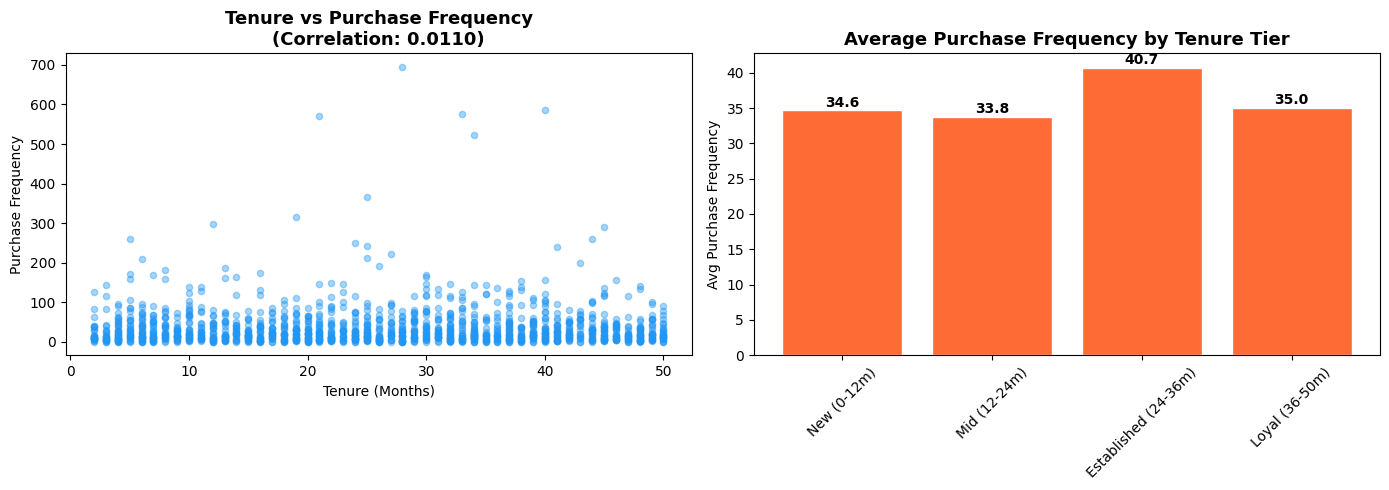

In [53]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Scatter plot tenure vs frequency
axes[0].scatter(tenure_freq['Tenure_Months'],
                tenure_freq['Purchase_Frequency'],
                alpha=0.4, color='#2196F3', s=20)
axes[0].set_title(f'Tenure vs Purchase Frequency\n(Correlation: {correlation:.4f})',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Purchase Frequency')

# Chart 2 - Avg frequency by tenure tier
axes[1].bar(tier_summary['Tenure_Tier'],
            tier_summary['Avg_Frequency'],
            color='#FF6B35', edgecolor='white')
axes[1].set_title('Average Purchase Frequency by Tenure Tier',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Purchase Frequency')
axes[1].tick_params(axis='x', rotation=45)

for bar, val in zip(axes[1].patches, tier_summary['Avg_Frequency']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Analysis
Correlation between Tenure and Purchase Frequency: r = 0.011 (~ 0)
ANOVA: F = 1.42, p = 0.24 → FAIL TO REJECT H0

Customer tenure has virtually no impact on purchase frequency — a correlation of 0.011 confirms there is essentially no linear
relationship between how long a customer has been with the business and how often they buy.

###Tenure Tier Summary:
* New (0-12m)          : 34.65 avg purchases | 3,577 avg revenue
* Mid (12-24m)         : 33.75 avg purchases | 3,392 avg revenue  ← lowest
* Established (24-36m) : 40.73 avg purchases | 4,200 avg revenue  ← highest
* Loyal (36-50m)       : 35.03 avg purchases | 3,620 avg revenue

Notably, Established customers (24-36m) show the highest frequency and revenue despite tenure not being a statistically significant
predictor - suggesting a mid-tenure engagement sweet spot that doesn't persist into the Loyal tier.

###Strategies for engagement and retention:
* Don't rely on tenure as a proxy for engagement - design activity-based triggers instead of tenure-based ones
* Re-engage Mid-tenure customers (12-24m) who show the lowest frequency and revenue - targeted campaigns at this stage could prevent further disengagement
* Investigate what drives Established segment's superior activity and replicate those triggers across other tenure groups
* Monitor Loyal customers (36-50m) for disengagement signals - their frequency drops below Established despite longer tenure, suggesting loyalty programs need refreshing after 36 months

# Q17-Analyze the relationship between delivery charges and order behavior. Are there opportunities to optimize delivery pricing to increase order quantities or revenue?

In [92]:
# ============================================================
# Q17: Delivery Charges vs Order Behavior
# ============================================================

# Delivery charge analysis by tier
delivery_analysis = df.groupby('Delivery_Tier', observed=True).agg(
    Transaction_Count= ('Transaction_ID','count'),
    Avg_Order_Value= ('Revenue', 'mean'),
    Avg_Quantity= ('Quantity', 'mean'),
    Total_Revenue= ('Revenue', 'sum'),
    Avg_Delivery_Charge= ('Delivery_Charges', 'mean')
).reset_index().round(2)
#display(delivery_analysis)

delivery_analysis['Revenue_%'] = (delivery_analysis['Total_Revenue'] /
                                  delivery_analysis['Total_Revenue'].sum() *100).round(2)
display(delivery_analysis)


,Delivery_Tier,Transaction_Count,Avg_Order_Value,Avg_Quantity,Total_Revenue,Avg_Delivery_Charge,Revenue_%
0,Low (0-6),26801,86.87,2.98,2328246.45,6.00,43.04
1,Medium (6-15),20639,110.39,3.99,2278304.41,7.93,42.12
2,High (15+),5321,150.93,14.16,803108.64,43.54,14.85


In [55]:
# Distribution breakdown
print("\nDelivery Charge Breakdown:")
print(f"Free Delivery (0)        : {(df['Delivery_Charges']==0).sum():,} transactions")
print(f"Standard (6-6.5)         : {df['Delivery_Charges'].between(6,6.5).sum():,} transactions")
print(f"PRemium (>6.5)           : {(df['Delivery_Charges'] >6.5).sum():,} transactions")


Delivery Charge Breakdown:
Free Delivery (0)        : 162 transactions
Standard (6-6.5)         : 42,663 transactions
PRemium (>6.5)           : 10,099 transactions


In [56]:
# Correlations
corr_revenue = df['Delivery_Charges'].corr(df['Revenue'])
corr_quantity = df['Delivery_Charges'].corr(df['Quantity'])
print(f"\nCorrelation - Delivery Charges vs Revenue : {corr_revenue:.4f}")
print(f"\nCorrelation - Delivery Charges vs Quantity : {corr_quantity:.4f}")


Correlation - Delivery Charges vs Revenue : 0.1834

Correlation - Delivery Charges vs Quantity : 0.1914


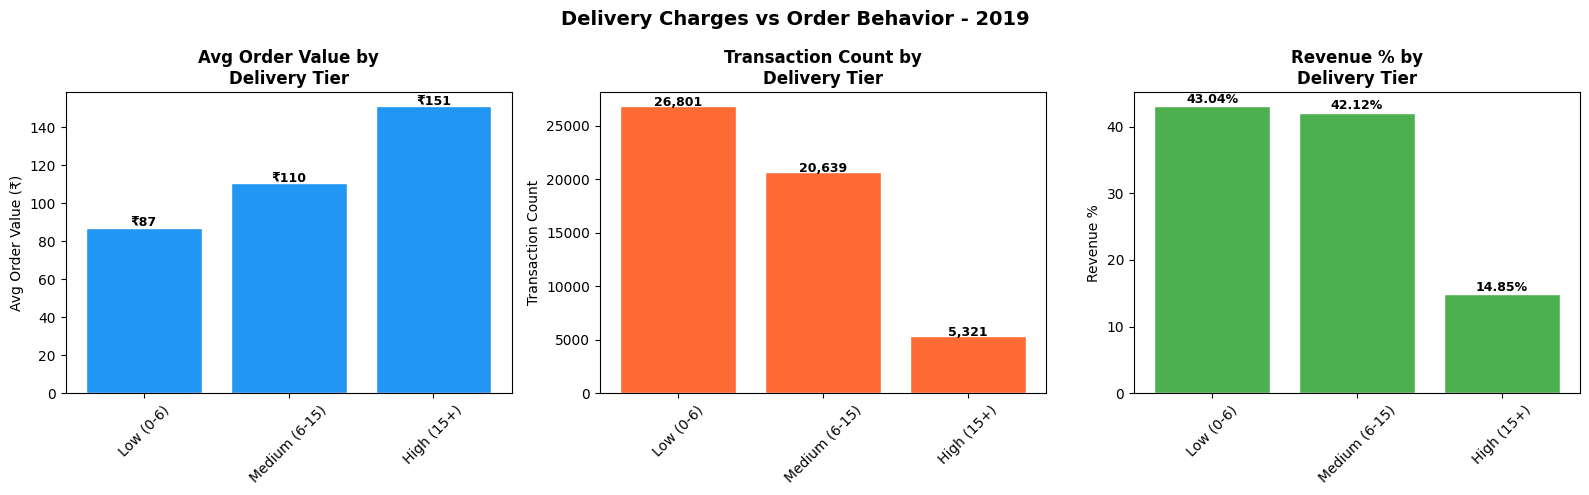

In [57]:
# Step 4: Visualise
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1 - Avg order value by tier
axes[0].bar(delivery_analysis['Delivery_Tier'],
            delivery_analysis['Avg_Order_Value'],
            color='#2196F3', edgecolor='white')
axes[0].set_title('Avg Order Value by\nDelivery Tier',
                  fontweight='bold')
axes[0].set_ylabel('Avg Order Value (₹)')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(axes[0].patches,
                    delivery_analysis['Avg_Order_Value']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.0f}',
                 ha='center', fontweight='bold', fontsize=9)

# Chart 2 - Transaction count by tier
axes[1].bar(delivery_analysis['Delivery_Tier'],
            delivery_analysis['Transaction_Count'],
            color='#FF6B35', edgecolor='white')
axes[1].set_title('Transaction Count by\nDelivery Tier',
                  fontweight='bold')
axes[1].set_ylabel('Transaction Count')
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(axes[1].patches,
                    delivery_analysis['Transaction_Count']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{int(val):,}',
                 ha='center', fontweight='bold', fontsize=9)

# Chart 3 - Revenue % by tier
axes[2].bar(delivery_analysis['Delivery_Tier'],
            delivery_analysis['Revenue_%'],
            color='#4CAF50', edgecolor='white')
axes[2].set_title('Revenue % by\nDelivery Tier',
                  fontweight='bold')
axes[2].set_ylabel('Revenue %')
axes[2].tick_params(axis='x', rotation=45)
for bar, val in zip(axes[2].patches,
                    delivery_analysis['Revenue_%']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val}%',
                 ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Delivery Charges vs Order Behavior - 2019',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Analysis
Delivery charge analysis reveals an inverse relationship between delivery cost and transaction volume - Low tier accounts for 51% of transactions while High tier accounts for only 10%. However, higher delivery tiers correlate with significantly higher order values (86 → 110 → 151) and quantities (3.0 → 4.0 → 14.2 items), suggesting bulk/premium buyers are concentrated in the High delivery tier.

Revenue is remarkably balanced across Low (43%) and Medium (42%) tiers despite their transaction volume difference - confirming that Medium tier customers compensate with higher per-transaction value.

Standard delivery (6-6.5) dominates at 80.6% of all transactions, indicating most customers accept a flat low delivery fee.

Correlations are weak (r=0.18 for revenue, r=0.19 for quantity) - delivery charges alone are not a strong predictor of order behavior.

###Opportunities to optimise delivery pricing:
* Introduce free delivery threshold (e.g. free delivery above 500) to encourage Low tier customers to increase basket size - converting them from 86 to 110+ avg order value
* Offer bulk delivery discounts for High tier customers (avg 14 items) to incentivise even larger orders from this valuable segment
* Investigate the 162 free delivery transactions - understand what
  products qualify and whether expanding free delivery eligibility
  could drive volume growth
* Keep standard delivery flat at 6-6.5 - 80.6% acceptance rate
  suggests customers are comfortable with this pricing

#Q18-Evaluate how taxes and delivery charges influence customer spending behavior. Are there opportunities to adjust pricing strategies to improve customer satisfaction and revenue?

In [58]:
# ============================================================
# Q18: Tax and Delivery Charges vs Spending Behavior
# ============================================================
gst_analysis = (
    df.groupby('GST')
    .agg(
        Transaction_Count=('Transaction_ID', 'count'),
        Avg_Order_Value=('Revenue', 'mean'),
        Total_Revenue=('Revenue', 'sum'),
        Avg_Quantity=('Quantity', 'mean')
    )
    .reset_index()
    .round(2)
)

gst_analysis['Revenue_%']= (gst_analysis['Total_Revenue'] / gst_analysis['Total_Revenue'].sum() * 100).round(2)
gst_analysis['GST_%']= (gst_analysis['GST'] * 100).astype(str) + '%'
display(gst_analysis)

,GST,Transaction_Count,Avg_Order_Value,Total_Revenue,Avg_Quantity,Revenue_%,GST_%
0,0.05,4145,176.86,733067.71,4.40,13.50,5.0%
1,0.10,21314,151.76,3234581.46,5.26,59.56,10.0%
2,0.12,122,57.91,7064.75,20.36,0.13,12.0%
3,0.18,27343,53.27,1456489.24,3.85,26.82,18.0%


In [59]:
print("=== Revenue by GST Rate ===")
display(gst_analysis[['GST_%', 'Transaction_Count',
                        'Avg_Order_Value', 'Total_Revenue',
                        'Avg_Quantity', 'Revenue_%']])


=== Revenue by GST Rate ===


,GST_%,Transaction_Count,Avg_Order_Value,Total_Revenue,Avg_Quantity,Revenue_%
0,5.0%,4145,176.86,733067.71,4.40,13.50
1,10.0%,21314,151.76,3234581.46,5.26,59.56
2,12.0%,122,57.91,7064.75,20.36,0.13
3,18.0%,27343,53.27,1456489.24,3.85,26.82


In [60]:
# Category level - GST vs revenue
category_gst= df.groupby(['Product_Category','GST']).agg(
    Transaction_Count=('Transaction_ID','count'),
    Avg_Order_Value= ('Revenue', 'mean'),
    Total_Revenue= ('Revenue','sum')
).reset_index().sort_values('Total_Revenue', ascending=False).round(2).head(10)
print("\n=== Top 10 Categories by Revenue with GST Rate ===")
display(category_gst)


=== Top 10 Categories by Revenue with GST Rate ===


,Product_Category,GST,Transaction_Count,Avg_Order_Value,Total_Revenue
16,Nest-USA,0.10,14013,195.44,2738702.08
2,Apparel,0.18,18126,46.06,834940.00
14,Nest,0.05,2198,237.73,522536.59
18,Office,0.10,6513,58.94,383853.84
6,Drinkware,0.18,3483,78.90,274809.08
4,Bags,0.18,1882,103.74,195239.63
12,Lifestyle,0.18,3092,40.80,126150.12
17,Notebooks & Journals,0.05,749,163.81,122697.04
15,Nest-Canada,0.10,317,241.86,76669.24
10,Headgear,0.05,771,75.40,58134.99


In [61]:
# Tax + Delivery burden
df['Tax_Amount']= (df['Avg_Price'] * df['Quantity'] * df['GST']).round(2)
df['Total_Burden']= (df['Tax_Amount'] + df['Delivery_Charges']).round(2)
df['Base_Revenue']= (df['Avg_Price'] * df['Quantity'] * (1 - df['Discount_Applied'] / 100)).round(2)
df['Burden_Pct']=  (df['Total_Burden'] / df['Revenue'] *100).round(2)

display(df.head(3))

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month_Number,Month_Name,Retention_Period,Order_Value,Month_Abbr,Month,Discount_pct,GST,Gender,Location,Tenure_Months,Discount_Applied,Revenue,Customer_Acquisition_Date,Customer_Type,Segment,Delivery_Tier,Tax_Amount,Total_Burden,Base_Revenue,Burden_Pct
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,Nest-USA,1,153.71,6.5,Used,1,January,Low Retention,153.71,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,160.21,2019-01-01,New,Gold,Medium (6-15),15.37,21.87,138.34,13.65
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,Nest-USA,1,153.71,6.5,Used,1,January,Low Retention,153.71,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,160.21,2019-01-01,New,Gold,Medium (6-15),15.37,21.87,138.34,13.65
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,January,Low Retention,2.05,Jan,Jan,10.0,0.1,M,Chicago,12,10.0,8.55,2019-01-01,New,Gold,Medium (6-15),0.20,6.70,1.84,78.36


In [62]:
print("\n=== Tax + Delivery Burden Stats ===")
print(f"Avg Tax Amount per transaction    : {df['Tax_Amount'].mean():.2f}")
print(f"Avg Delivery Charge per transaction: {df['Delivery_Charges'].mean():.2f}")
print(f"Avg Total Burden per transaction  : {df['Total_Burden'].mean():.2f}")
print(f"Avg Burden as % of Revenue        : {df['Burden_Pct'].mean():.2f}%")


=== Tax + Delivery Burden Stats ===
Avg Tax Amount per transaction    : 9.72
Avg Delivery Charge per transaction: 10.52
Avg Total Burden per transaction  : 20.24
Avg Burden as % of Revenue        : 34.81%


In [63]:
#  Correlation
corr_tax_order= df['Tax_Amount'].corr(df['Base_Revenue'])
corr_burden_order= df['Total_Burden'].corr(df['Base_Revenue'])

print(f"\nCorrelation — Tax Amount vs Base Revenue    : {corr_tax_order:.4f}")
print(f"Correlation — Total Burden vs Base Revenue  : {corr_burden_order:.4f}")


Correlation — Tax Amount vs Base Revenue    : 0.8787
Correlation — Total Burden vs Base Revenue  : 0.6220


# Analysis:
Tax and delivery charges represent a significant portion of customer spending - averaging 20.24 per transaction (34.81% of total bill), split almost equally between tax (9.72) and delivery (10.52).

GST analysis reveals that higher tax rate categories (18%) show lower average order values (53.27) compared to lower tax rate categories (5% → 176.86). However this is driven by product mix rather than tax sensitivity - premium products like Nest devices fall in the 10% GST bracket while high-volume low-value items like Apparel carry 18% GST.

The strong correlation between tax amount and base revenue (r=0.88) confirms tax is proportional to spending - not a deterrent to it.
Customers buying higher value products naturally incur higher tax.

10% GST category (Nest-USA, Office) dominates revenue at 59.56%, while 18% GST category (Apparel, Drinkware, Bags) contributes 26.82%
despite having the highest transaction count.

###Opportunities to adjust pricing strategy:
* The 35% burden rate is high - introducing free delivery above a
  minimum order threshold (e.g. 300+) would directly reduce
  perceived burden and encourage larger baskets
* Since tax is non-negotiable, focus pricing strategy on delivery
  charge optimisation - it's the only controllable component of
  the burden
* Promote low-GST premium categories (Nest at 5-10%) more
  aggressively - customers get higher value products with
  relatively lower tax burden
* For high GST categories (Apparel at 18%), consider absorbing
  delivery charges on orders above a threshold to offset the
  higher tax burden and improve customer satisfaction

#Q19-Identify seasonal trends in sales by category and location. How can the company prepare for peak and off-peak seasons to maximize revenue?

In [64]:
# ============================================================
# Q19: Seasonal Trends by Category and Location
# ============================================================
#  Monthly revenue by category
category_monthly = df.groupby(['Month_Number', 'Month_Name', 'Product_Category'])['Revenue']\
.sum().reset_index().sort_values(['Month_Number', 'Revenue'],ascending=[True, False]).round(2)
#display(category_monthly)

# Top 5 categories only
top_5_categories = df.groupby('Product_Category')['Revenue'].sum().nlargest(5).index.tolist()
print("Top 5 Categories:", top_5_categories)

category_seasonal = category_monthly[category_monthly['Product_Category'].isin(top_5_categories)]
#display(category_seasonal)

Top 5 Categories: ['Nest-USA', 'Apparel', 'Nest', 'Office', 'Drinkware']


In [65]:
# Pivot for heatmap
category_pivot = category_seasonal.pivot(
    index='Product_Category',
    columns='Month_Name',
    values='Revenue'
).fillna(0)


# Reorder months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
print("\n=== Monthly Revenue by Top 5 Categories ===")
display(category_pivot[month_order].round(2))


=== Monthly Revenue by Top 5 Categories ===


Month_Name,January,February,March,April,May,June,July,August,September,October,November,December
Product_Category,,,,,,,,,,,,
Apparel,59431.27,55661.17,81498.41,115260.71,81415.08,63460.78,93079.05,83578.08,72906.87,39027.08,26420.31,63201.19
Drinkware,21219.41,21274.79,30861.78,34727.83,21885.39,21903.45,17287.15,31100.94,23611.20,28288.90,9657.06,12991.18
Nest,0.00,0.00,0.00,0.00,0.00,0.00,0.00,21236.12,66914.64,112456.48,175989.73,145939.62
Nest-USA,313966.20,210822.45,206833.15,201302.79,186489.78,203295.41,230853.96,209987.49,174545.32,226792.01,280929.45,292884.07
Office,45014.19,30268.70,41959.92,47149.40,32387.78,28281.91,33493.55,34911.50,20187.38,19245.90,29344.37,21609.24


In [96]:
# Monthly revenue by location
location_monthly = (
    df.groupby(['Month_Number', 'Month_Name', 'Location'])['Revenue'].sum().reset_index()
    .sort_values(['Month_Number', 'Revenue']).round(2)
)
#display(location_monthly)

location_pivot= location_monthly.pivot(
    index='Location',
    columns='Month_Name',
    values='Revenue'
).fillna(0)

print("\n=== Monthly Revenue by Location ===")
display(location_pivot[month_order].round(2))


=== Monthly Revenue by Location ===


Month_Name,January,February,March,April,May,June,July,August,September,October,November,December
Location,,,,,,,,,,,,
California,188256.82,109233.06,117489.45,146309.75,104368.97,113830.15,145355.09,141566.28,129613.36,132952.62,152922.80,196634.52
Chicago,131120.32,137203.43,144259.49,179209.11,131993.75,113897.08,158451.89,188776.38,152030.41,156816.61,188928.51,206003.96
New Jersey,38017.58,34837.03,23359.22,53073.18,33433.11,45952.47,27437.72,26920.45,29377.22,46737.19,55528.91,56209.41
New York,96872.86,53077.84,114384.86,77613.24,90959.12,76793.46,99133.58,98786.36,64844.40,120821.05,122614.52,80631.35
Washington DC,41275.30,43091.76,19746.24,22915.49,7135.42,14360.61,22899.28,22777.68,24969.40,24782.91,30999.87,21609.26


In [67]:
# Peak month per category
print("=== Peak Month per Category ===")
peak_category = (
    category_monthly[
        category_monthly['Product_Category'].isin(top_5_categories)
    ].sort_values('Revenue', ascending = False)
    .groupby('Product_Category')
    .first()
    .reset_index()[['Product_Category', 'Month_Name', 'Revenue']]
    .rename(columns={'Month_Name': 'Peak_Month',
                     'Revenue': 'Peak_Revenue'})
    .sort_values('Peak_Revenue', ascending=False)
)
display(peak_category)

=== Peak Month per Category ===


,Product_Category,Peak_Month,Peak_Revenue
3,Nest-USA,January,313966.20
2,Nest,November,175989.73
0,Apparel,April,115260.71
4,Office,April,47149.40
1,Drinkware,April,34727.83


In [68]:
# Peak month per location
print("=== Peak Month per Location ===")
peak_location = (
    location_monthly.sort_values('Revenue', ascending=False)
    .groupby('Location')
    .first()
    .reset_index()[['Location', 'Month_Name', 'Revenue']]
    .rename(columns={
        'Month_Name': 'Peak_Month','Revenue': 'Peak_Revenue'
    })
    .sort_values('Peak_Revenue', ascending=False)
)
display(peak_location)

=== Peak Month per Location ===


,Location,Peak_Month,Peak_Revenue
1,Chicago,December,206003.96
0,California,December,196634.52
3,New York,November,122614.52
2,New Jersey,December,56209.41
4,Washington DC,February,43091.76


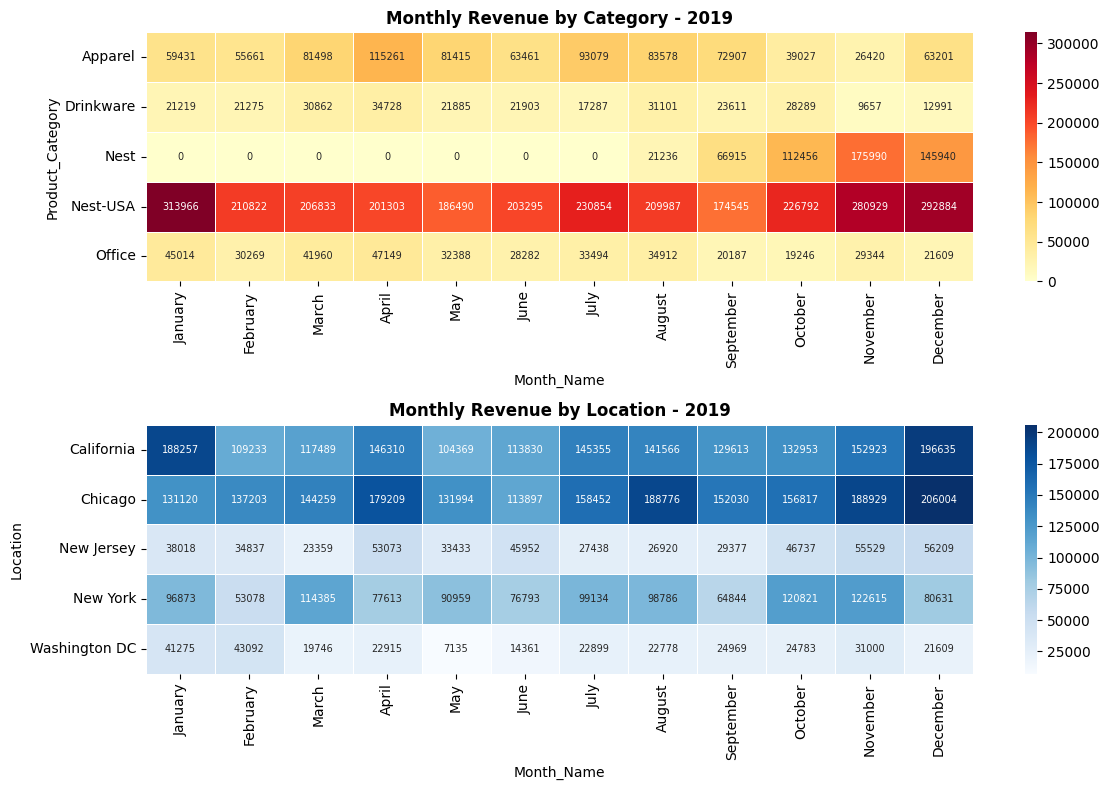

In [100]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
sns.heatmap(category_pivot[month_order], annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5,
            annot_kws={'size': 7}, ax=axes[0])
axes[0].set_title('Monthly Revenue by Category - 2019',
                  fontsize=12, fontweight='bold')
sns.heatmap(location_pivot[month_order], annot=True, fmt='.0f',
            cmap='Blues', linewidths=0.5,
            annot_kws={'size': 7}, ax=axes[1])
axes[1].set_title('Monthly Revenue by Location - 2019',
                  fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#Analysis:
Seasonal analysis reveals clear patterns across categories and locations.
###Category highlights:
* Nest-USA peaks in January (3.13L) - strong new-year demand
* Nest category shows zero revenue until August then surges to
  1.75L by November - likely a mid-year launch or Q4 seasonality
* Apparel, Office and Drinkware all peak in April - clear spring
  buying season worth targeting with bundle promotions

###Location highlights:
* Chicago, California and New Jersey all peak in December -
  classic holiday season effect
* New York peaks slightly earlier in November
* Washington DC uniquely peaks in February - worth investigating
  for location-specific campaigns

###Strategies:
* Stock Nest-USA heavily before January and November
* Run Apparel/Office/Drinkware bundles in March ahead of April peak
* Increase marketing spend in Chicago and California in Q4
* Investigate Nest's H1 absence - resolving availability could
  unlock significant first-half revenue

# Q20-Analyze daily sales trends to identify high-performing and low-performing days. What strategies can be implemented to boost sales on slower days?

In [106]:
# ============================================================
# Q20: Daily Sales Trends
# ============================================================

# Add day of week to df
df['Day_of_Week']= df['Transaction_Date'].dt.day_name()
df['Day_Number']= df['Transaction_Date'].dt.day_of_week
#display(df.head(3))

# Daily Revenue
daily_revenue = df.groupby(['Transaction_Date', 'Day_of_Week', 'Day_Number']).agg(
    Total_Revenue= ('Revenue', 'sum'),
    Transaction_Count= ('Transaction_ID', 'count'),
    Unique_Customers= ('CustomerID', 'nunique')
).reset_index().sort_values('Transaction_Date').round(2)
display(daily_revenue.head(5))

,Transaction_Date,Day_of_Week,Day_Number,Total_Revenue,Transaction_Count,Unique_Customers
0,2019-01-01,Tuesday,1,9067.23,89,7
1,2019-01-02,Wednesday,2,15311.25,115,10
2,2019-01-03,Thursday,3,29221.81,207,14
3,2019-01-04,Friday,4,19555.70,169,6
4,2019-01-05,Saturday,5,21323.08,189,9


In [107]:
# Day of week analysis
dow_analysis  = daily_revenue.groupby(['Day_Number','Day_of_Week']).agg(
    Avg_Revenue = ('Total_Revenue','mean'),
    Avg_Transactions = ('Transaction_Count', 'mean'),
    Avg_Customers = ('Unique_Customers', 'mean')
).reset_index().sort_values('Day_Number').round(2)

print("=== Average Daily Performance by Day of Week ===")
display(dow_analysis)

=== Average Daily Performance by Day of Week ===


,Day_Number,Day_of_Week,Avg_Revenue,Avg_Transactions,Avg_Customers
0,0,Monday,7983.59,85.85,5.75
1,1,Tuesday,8544.81,87.00,5.85
2,2,Wednesday,18504.01,170.90,10.48
3,3,Thursday,18843.46,173.08,10.31
4,4,Friday,19339.45,178.19,11.10
5,5,Saturday,15310.59,157.25,9.15
6,6,Sunday,15755.97,163.83,8.94


In [71]:
# Top and Bottom 10 Days
print("\n=== Top 10 Best Performing Days ===")
display(daily_revenue.nlargest(10, 'Total_Revenue')[['Transaction_Date', 'Day_of_Week',
          'Total_Revenue', 'Transaction_Count']].reset_index(drop=True))

print("\n=== Top 10 Worst Performing Days ===")
display(daily_revenue.nsmallest(10, 'Total_Revenue')
        [['Transaction_Date', 'Day_of_Week',
          'Total_Revenue', 'Transaction_Count']]
        .reset_index(drop=True))


=== Top 10 Best Performing Days ===


,Transaction_Date,Day_of_Week,Total_Revenue,Transaction_Count
0,2019-04-05,Friday,60197.17,190
1,2019-11-27,Wednesday,56961.48,335
2,2019-04-18,Thursday,54594.56,261
3,2019-07-18,Thursday,43030.34,249
4,2019-08-02,Friday,40858.30,292
5,2019-02-14,Thursday,36353.14,183
6,2019-12-11,Wednesday,33447.13,210
7,2019-07-13,Saturday,32397.42,311
8,2019-12-18,Wednesday,32310.75,274
9,2019-12-15,Sunday,31180.02,208



=== Top 10 Worst Performing Days ===


,Transaction_Date,Day_of_Week,Total_Revenue,Transaction_Count
0,2019-05-28,Tuesday,2009.57,43
1,2019-08-20,Tuesday,3281.66,32
2,2019-02-05,Tuesday,3899.51,41
3,2019-09-02,Monday,4490.16,81
4,2019-02-25,Monday,4690.31,57
5,2019-07-29,Monday,4708.96,105
6,2019-05-27,Monday,4712.34,56
7,2019-06-10,Monday,4713.89,60
8,2019-07-02,Tuesday,5025.27,47
9,2019-02-12,Tuesday,5083.37,81


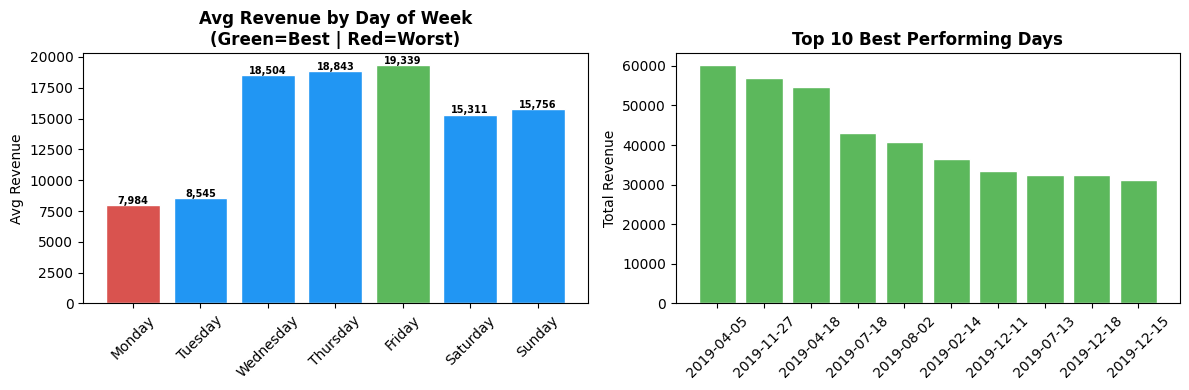

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_sorted = dow_analysis.set_index('Day_of_Week').loc[day_order].reset_index()
colors = ['#d9534f' if x == dow_sorted['Avg_Revenue'].min()
          else '#5cb85c' if x == dow_sorted['Avg_Revenue'].max()
          else '#2196F3' for x in dow_sorted['Avg_Revenue']]
axes[0].bar(dow_sorted['Day_of_Week'], dow_sorted['Avg_Revenue'],
            color=colors, edgecolor='white')
axes[0].set_title('Avg Revenue by Day of Week\n(Green=Best | Red=Worst)',
                  fontweight='bold')
axes[0].set_ylabel('Avg Revenue')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(axes[0].patches, dow_sorted['Avg_Revenue']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{val:,.0f}', ha='center', fontsize=7, fontweight='bold')

axes[1].bar(daily_revenue.nlargest(10, 'Total_Revenue')['Transaction_Date'].astype(str),
            daily_revenue.nlargest(10, 'Total_Revenue')['Total_Revenue'],
            color='#5cb85c', edgecolor='white')
axes[1].set_title('Top 10 Best Performing Days',
                  fontweight='bold')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Analysis:
Daily sales analysis reveals a strong day-of-week pattern - Friday
(19,339 avg), Thursday (18,843) and Wednesday (18,504) consistently
outperform Monday (7,983) and Tuesday (8,544), with mid-week revenue
nearly 2.5x higher than early-week revenue.

The single best day of 2019 was April 5 (Friday, 60,197), followed
by November 27 (56,961) - Black Friday - confirming that shopping
events drive exceptional daily revenue. Valentine's Day (Feb 14,
36,353) also ranks among the top performers, highlighting the
importance of event-driven campaigns.

Worst performing days are concentrated on Mondays and Tuesdays -
May 28 recorded the lowest revenue of the year at just 2,009.

###Strategies to boost slower days:
* Launch Monday/Tuesday specific flash sales or limited-time
  offers to drive early-week traffic
* Schedule email and push notification campaigns for Sunday
  evening to prime customers for Monday purchases
* Build a promotional calendar around key shopping events -
  Black Friday, Valentine's Day clearly drive exceptional
  performance and should be planned months in advance
* Introduce midweek loyalty rewards (Wed-Fri) to maintain
  the natural peak and further widen the gap from slow days
  

In [109]:
%%capture
!jupyter nbconvert --to html \
  "/content/drive/MyDrive/Colab Notebooks/Scaler_Project1_Ecommerce_Analysis_Final.ipynb" \
  --output "/content/drive/MyDrive/Colab Notebooks/Projects/Scaler_Project_1/Final_Submission_1.html"

print("HTML saved!")